# 🏥 Healthcare Data Analysis — Full Pipeline
**Steps covered:**
1. Install & Import Libraries
2. Load Data
3. Data Cleaning
4. Descriptive Analysis
5. Outlier Detection & Treatment
6. Full Analysis
7. Dashboard (5 pages)

---
> **How to use:** Run cells top-to-bottom. Update `FILE_PATH` in Cell 2 to point to your Excel file.

## ① Install & Import Libraries

In [ ]:
# Install required libraries (run once)
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'openpyxl', 'matplotlib',
                'seaborn', 'scipy', 'numpy', '-q'], check=True)
print('✅ Libraries ready')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('✅ All imports successful')

✅ All imports successful


## ② Load Data

In [4]:
# ─── UPDATE THIS PATH TO YOUR FILE ───────────────────────────────────────────
FILE_PATH = 'final_hc_python.xlsx'
# ─────────────────────────────────────────────────────────────────────────────

df_raw = pd.read_csv("final hc python.csv")
print(f'✅ Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Sheets detected — using first sheet by default.')
df_raw.head()

✅ Loaded: 10,140 rows × 53 columns
Sheets detected — using first sheet by default.


,Patient_ID,Survey_Date,Gender,Age,Department,Admission_Type,Length_of_Stay_Days,Waiting_Time_Minutes,Appointment_Delay_Minutes,Doctor_Workload_Patients_Per_Doctor_Day,...,doctor_specialization,treatment_type,treatment_cost,treatment_success,readmission_30_days,diagnosis_accuracy,patient_segment,insurance_approval_time,profit_per_patient,lifetime_value_patient
0,P100001,3/8/2025,Female,43,Oncology,Scheduled,6.4,36,14,13.1,...,Pediatrics,Medication,1709,Ongoing,No,Confirmed,Regular,47,418.043794,2090.218972
1,P100002,3/22/2024,Female,60,Cardiology,Scheduled,3.8,50,15,20.3,...,Pediatrics,Medication,13383,Success,No,Estimated,Insurance,87,2828.296058,22626.368460
2,P100003,2/2/2024,Male,39,General Surgery,Scheduled,3.8,47,34,22.4,...,Pediatrics,Medication,14237,Success,No,Estimated,Regular,9,2089.748512,6269.245535
3,P100004,4/22/2024,Female,55,Orthopedics,Emergency,5.0,37,20,21.8,...,General,Therapy,9938,Success,No,Confirmed,Insurance,38,1375.020370,1375.020370
4,P100005,6/3/2025,Male,28,Oncology,Referral,7.6,28,27,16.3,...,Pediatrics,Therapy,13125,Success,No,Confirmed,Insurance,65,1845.509682,14764.077460


In [6]:
print('=== COLUMN TYPES ===')
print(df_raw.dtypes.to_string())
print('\n=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string())

=== COLUMN TYPES ===
Patient_ID                                  object
Survey_Date                                 object
Gender                                      object
Age                                          int64
Department                                  object
Admission_Type                              object
Length_of_Stay_Days                        float64
Waiting_Time_Minutes                         int64
Appointment_Delay_Minutes                    int64
Doctor_Workload_Patients_Per_Doctor_Day    float64
Emergency_Response_Time_Minutes             object
Service_Rating                               int64
Doctor_Rating                              float64
Cleanliness_Rating                         float64
Staff_Rating                                 int64
NPS_Score                                    int64
Feedback_Category                           object
Feedback_Text                               object
Complaint_Count                              int64
Follow_Up_

## ③ Data Cleaning
Steps:
- Fix column data types
- Impute missing values (median for numeric, mode for categorical)
- Remove duplicate rows
- Deduplicate Patient IDs (keep most recent visit)

In [10]:
df = df_raw.copy()

# ── Fix data types ────────────────────────────────────────────────────────
df['Emergency_Response_Time_Minutes'] = pd.to_numeric(
    df['Emergency_Response_Time_Minutes'], errors='coerce')
if 'Survey_Date' in df.columns:
    df['Survey_Date'] = pd.to_datetime(df['Survey_Date'], errors='coerce')

# ── Impute missing values ─────────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

for c in num_cols:
    n = df[c].isnull().sum()
    if n > 0:
        df[c].fillna(df[c].median(), inplace=True)
        print(f'  [numeric]  {c}: {n} NaN → filled with median ({df[c].median():.2f})')

for c in cat_cols:
    n = df[c].isnull().sum()
    if n > 0:
        df[c].fillna(df[c].mode()[0], inplace=True)
        print(f'  [category] {c}: {n} NaN → filled with mode')

# ── Remove duplicate rows ─────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f'\n  Duplicate rows removed: {before - len(df)}')

# ── Deduplicate Patient IDs (keep most recent visit) ──────────────────────
if 'Patient_ID' in df.columns and 'Survey_Date' in df.columns:
    before = len(df)
    df.sort_values('Survey_Date', ascending=False, inplace=True)
    df.drop_duplicates(subset='Patient_ID', keep='first', inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'  Duplicate Patient IDs removed: {before - len(df)}')

print(f'\n✅ Clean shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Remaining missing: {df.isnull().sum().sum()}')
df.head()

  [numeric]  Emergency_Response_Time_Minutes: 208 NaN → filled with median (12.40)
  [numeric]  Doctor_Rating: 152 NaN → filled with median (5.00)
  [numeric]  Cleanliness_Rating: 122 NaN → filled with median (5.00)
  [numeric]  Treatment_Cost_USD: 152 NaN → filled with median (4301.72)
  [category] Feedback_Text: 183 NaN → filled with mode
  [category] Hospital_Branch: 119 NaN → filled with mode
  [category] Insurance_Type: 202 NaN → filled with mode
  [category] equipment_used: 1988 NaN → filled with mode

  Duplicate rows removed: 0
  Duplicate Patient IDs removed: 140

✅ Clean shape: 10,000 rows × 53 columns
   Remaining missing: 0


,Patient_ID,Survey_Date,Gender,Age,Department,Admission_Type,Length_of_Stay_Days,Waiting_Time_Minutes,Appointment_Delay_Minutes,Doctor_Workload_Patients_Per_Doctor_Day,...,doctor_specialization,treatment_type,treatment_cost,treatment_success,readmission_30_days,diagnosis_accuracy,patient_segment,insurance_approval_time,profit_per_patient,lifetime_value_patient
0,P100710,2025-12-31,Male,89,Cardiology,Scheduled,6.0,51,11,19.5,...,General,Surgery,12046,Success,No,Confirmed,Insurance,80,2628.008034,5256.016068
1,P103260,2025-12-31,Male,26,General Surgery,Scheduled,2.6,35,16,13.8,...,General,Surgery,16670,Failed,No,Confirmed,Insurance,78,2688.129020,10752.516080
2,P106450,2025-12-31,Female,70,Emergency,Emergency,3.7,39,13,26.0,...,Cardiology,Therapy,10501,Success,No,Confirmed,Regular,50,2609.445902,5218.891804
3,P104687,2025-12-31,Male,42,Oncology,Referral,5.7,35,12,9.9,...,Orthopedics,Surgery,17798,Success,No,Estimated,Regular,29,2140.793839,4281.587678
4,P107733,2025-12-31,Female,33,Maternity,Scheduled,0.7,20,10,18.5,...,General,Medication,7078,Success,No,Estimated,Regular,50,1611.714433,14505.429900


## ④ Descriptive Analysis

In [11]:
num_cols = df.select_dtypes(include='number').columns
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurt()

print('=== DESCRIPTIVE STATISTICS ===')
desc[['mean','std','min','25%','50%','75%','max','skewness','kurtosis']].round(2)

=== DESCRIPTIVE STATISTICS ===


,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,37.45,21.18,0.00,21.00,37.00,53.00,90.00,0.13,-0.68
Length_of_Stay_Days,3.78,1.75,0.20,2.50,3.80,5.00,10.30,0.12,-0.40
Waiting_Time_Minutes,35.27,14.70,5.00,25.00,35.00,45.00,98.00,0.19,-0.21
Appointment_Delay_Minutes,18.65,10.33,0.00,11.00,18.00,26.00,56.00,0.20,-0.33
Doctor_Workload_Patients_Per_Doctor_Day,18.24,4.96,6.00,14.70,18.00,21.50,36.30,0.24,-0.16
Emergency_Response_Time_Minutes,12.49,3.92,2.00,9.90,12.40,15.10,29.70,0.08,-0.06
Service_Rating,3.74,0.82,1.00,3.00,4.00,4.00,5.00,-0.47,0.06
Doctor_Rating,4.53,0.56,2.00,4.00,5.00,5.00,5.00,-0.68,-0.52
Cleanliness_Rating,4.58,0.50,3.00,4.00,5.00,5.00,5.00,-0.33,-1.83
Staff_Rating,4.37,0.51,2.00,4.00,4.00,5.00,5.00,0.26,-1.22


In [12]:
cat_cols = df.select_dtypes(include=['object','string']).columns
print('=== CATEGORICAL COLUMNS SUMMARY ===')
for c in cat_cols:
    vc = df[c].value_counts()
    print(f'\n▸ {c} ({df[c].nunique()} unique):')
    print(vc.head(5).to_string())

=== CATEGORICAL COLUMNS SUMMARY ===

▸ Patient_ID (10000 unique):
Patient_ID
P100710    1
P100688    1
P107651    1
P101408    1
P102088    1

▸ Gender (5 unique):
Gender
Female      5389
Male        4522
MALE          40
female        32
 Female       17

▸ Department (12 unique):
Department
Emergency          1997
Pediatrics         1467
Cardiology         1406
General Surgery    1267
Orthopedics        1262

▸ Admission_Type (3 unique):
Admission_Type
Scheduled    4290
Emergency    3345
Referral     2365

▸ Feedback_Category (4 unique):
Feedback_Category
Suggestion     5056
Praise         3300
Complaint      1643
 Suggestion       1

▸ Feedback_Text (24 unique):
Feedback_Text
More seating in the waiting area would improve comfort.         830
Improved signage could make navigation easier for patients.     635
Better status updates would help patients understand delays.    627
Self-service registration kiosks could speed up check-in.       621
More follow-up communication after visit

## ⑤ Outlier Detection & Treatment (IQR Capping)

In [13]:
outlier_cols = [
    'Waiting_Time_Minutes', 'Appointment_Delay_Minutes',
    'Length_of_Stay_Days', 'Treatment_Cost_USD',
    'profit_per_patient', 'lifetime_value_patient',
    'Doctor_Workload_Patients_Per_Doctor_Day',
    'service_duration_minutes', 'system_downtime_minutes',
    'queue_length', 'insurance_approval_time', 'treatment_cost'
]
# Filter to only columns that exist
outlier_cols = [c for c in outlier_cols if c in df.columns]

summary_rows = []
for c in outlier_cols:
    Q1, Q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    summary_rows.append({'Column': c, 'Lower Fence': round(lo,2),
                         'Upper Fence': round(hi,2), 'Outliers Found': n_out})

summary_df = pd.DataFrame(summary_rows)
print('=== OUTLIER DETECTION SUMMARY ===')
print(summary_df.to_string(index=False))

=== OUTLIER DETECTION SUMMARY ===
                                 Column  Lower Fence  Upper Fence  Outliers Found
                   Waiting_Time_Minutes        -5.00        75.00              39
              Appointment_Delay_Minutes       -11.50        48.50              30
                    Length_of_Stay_Days        -1.25         8.75              24
                     Treatment_Cost_USD      -253.51      8992.58              20
                     profit_per_patient     -2025.84      5862.55               7
                 lifetime_value_patient    -14332.80     31802.14             322
Doctor_Workload_Patients_Per_Doctor_Day         4.50        31.70              41
               service_duration_minutes       -54.00       178.00               0
                system_downtime_minutes       -15.50        44.50               0
                           queue_length       -25.88        75.12               0
                insurance_approval_time       -57.50       178.5

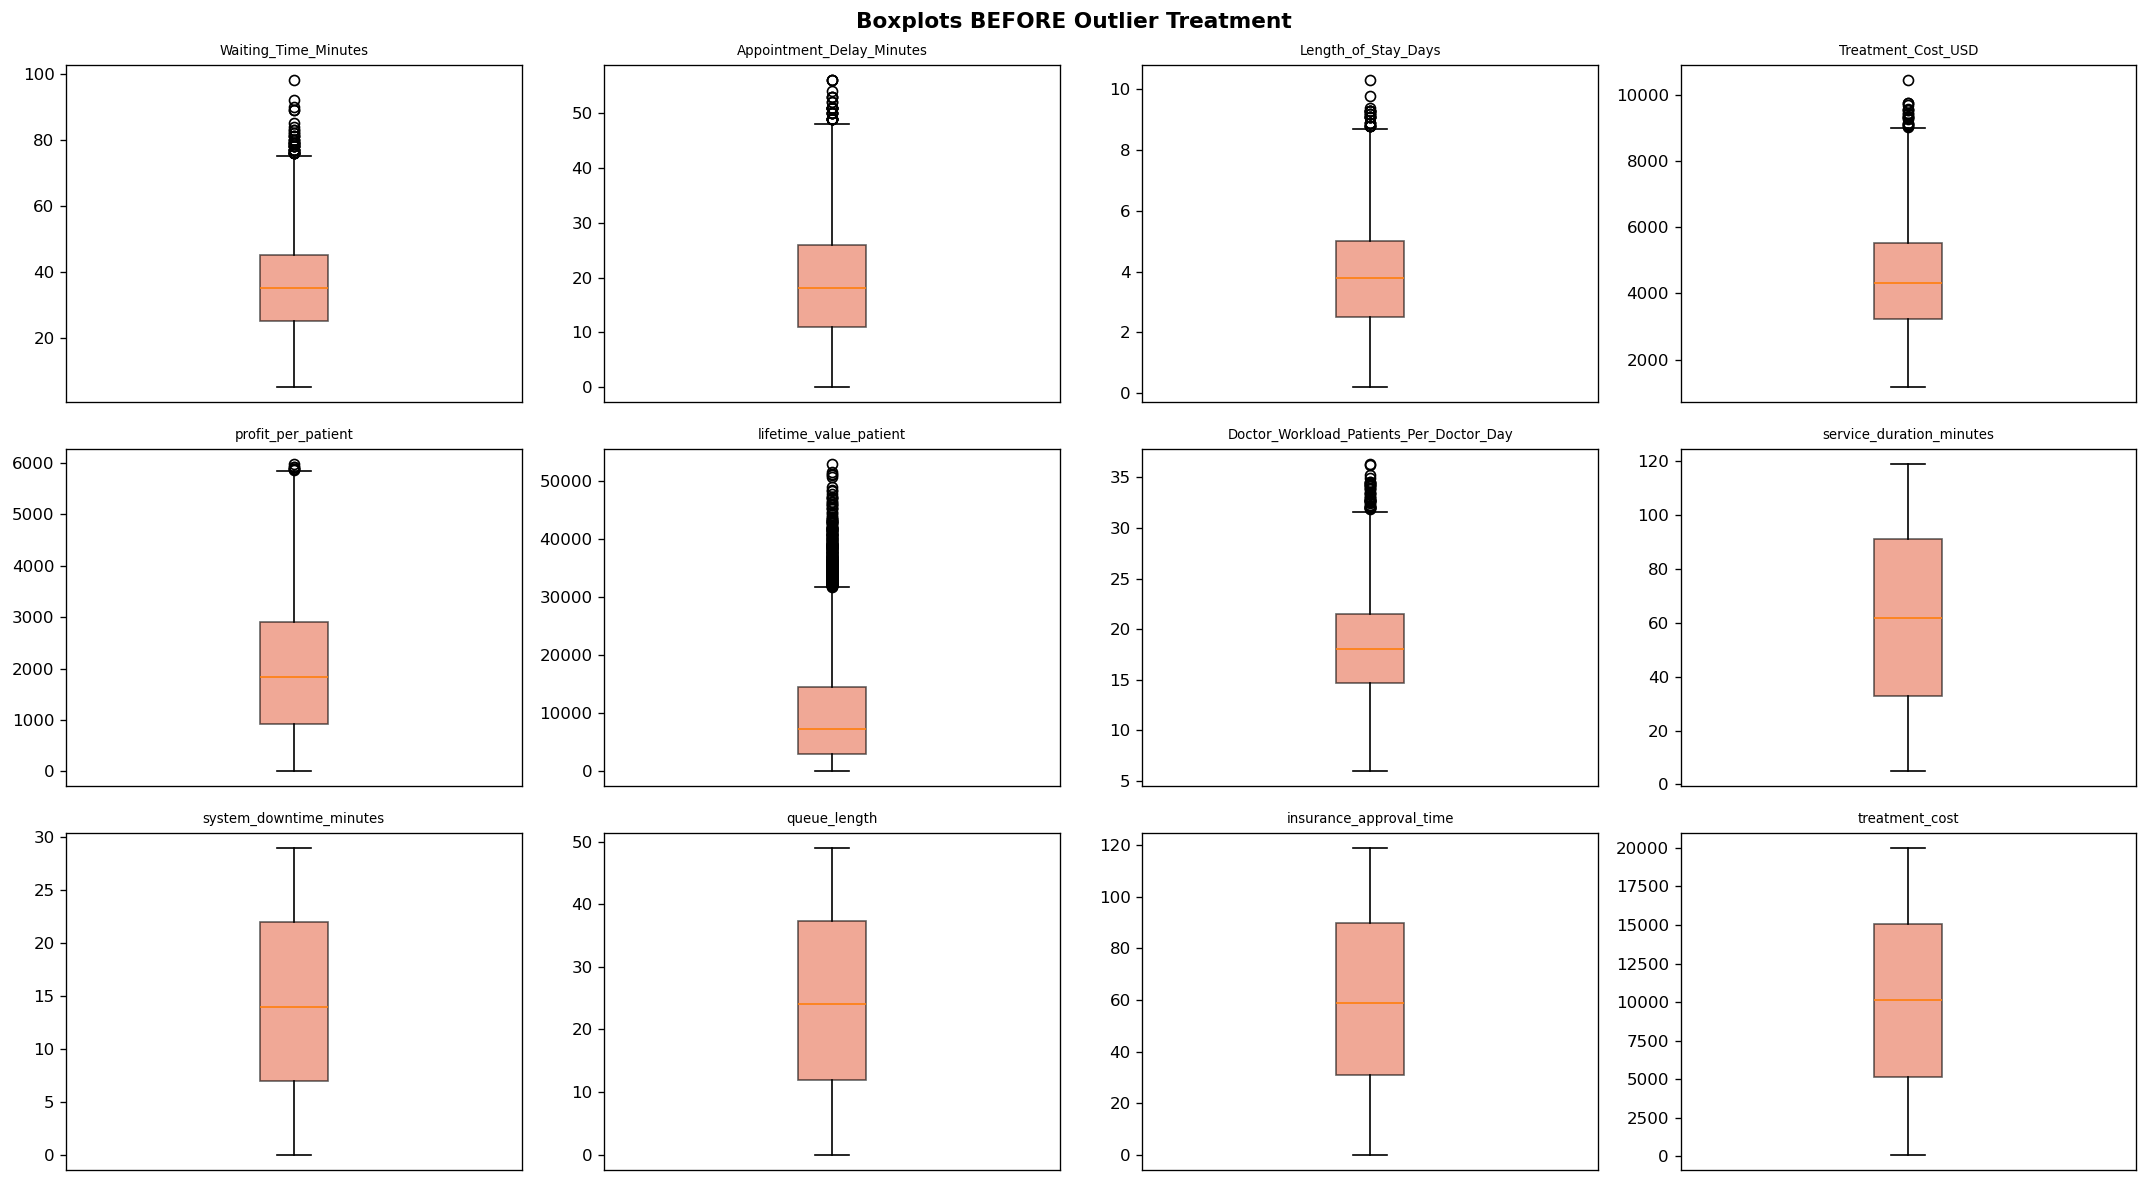

In [14]:
# Visualise before capping
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, c in enumerate(outlier_cols[:12]):
    axes[i].boxplot(df[c].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#E76F51', alpha=0.6))
    axes[i].set_title(c, fontsize=8)
    axes[i].set_xticks([])
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Boxplots BEFORE Outlier Treatment', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

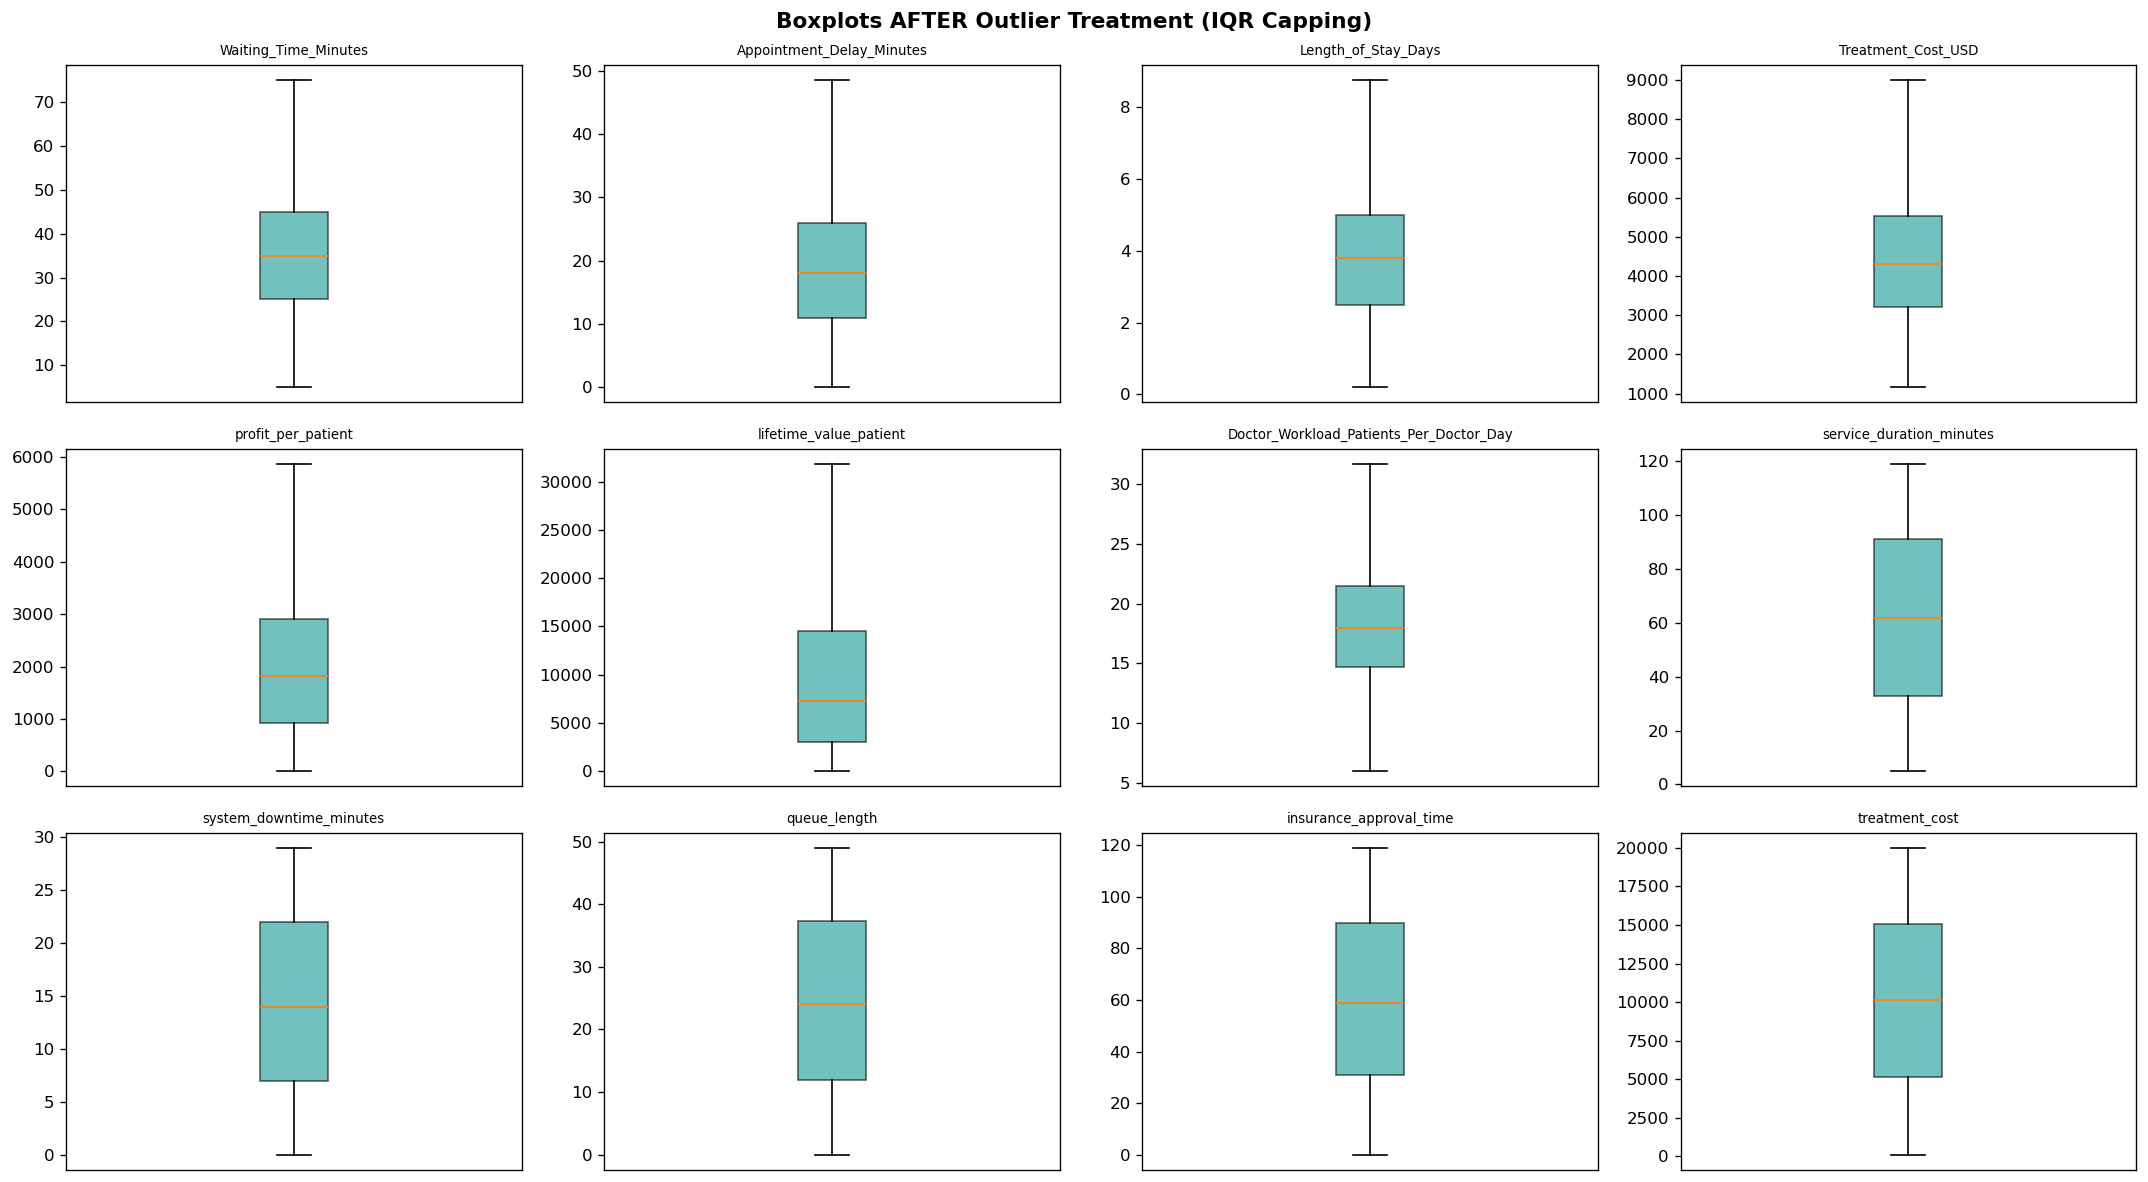

✅ Outlier treatment complete. Working with df_clean from here.


In [15]:
# Apply IQR capping
df_clean = df.copy()
for c in outlier_cols:
    Q1, Q3 = df_clean[c].quantile(0.25), df_clean[c].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_clean[c] = df_clean[c].clip(lo, hi)

# Visualise after capping
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()
for i, c in enumerate(outlier_cols[:12]):
    axes[i].boxplot(df_clean[c].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#159895', alpha=0.6))
    axes[i].set_title(c, fontsize=8)
    axes[i].set_xticks([])
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Boxplots AFTER Outlier Treatment (IQR Capping)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()
print('✅ Outlier treatment complete. Working with df_clean from here.')

## ⑥ Analysis

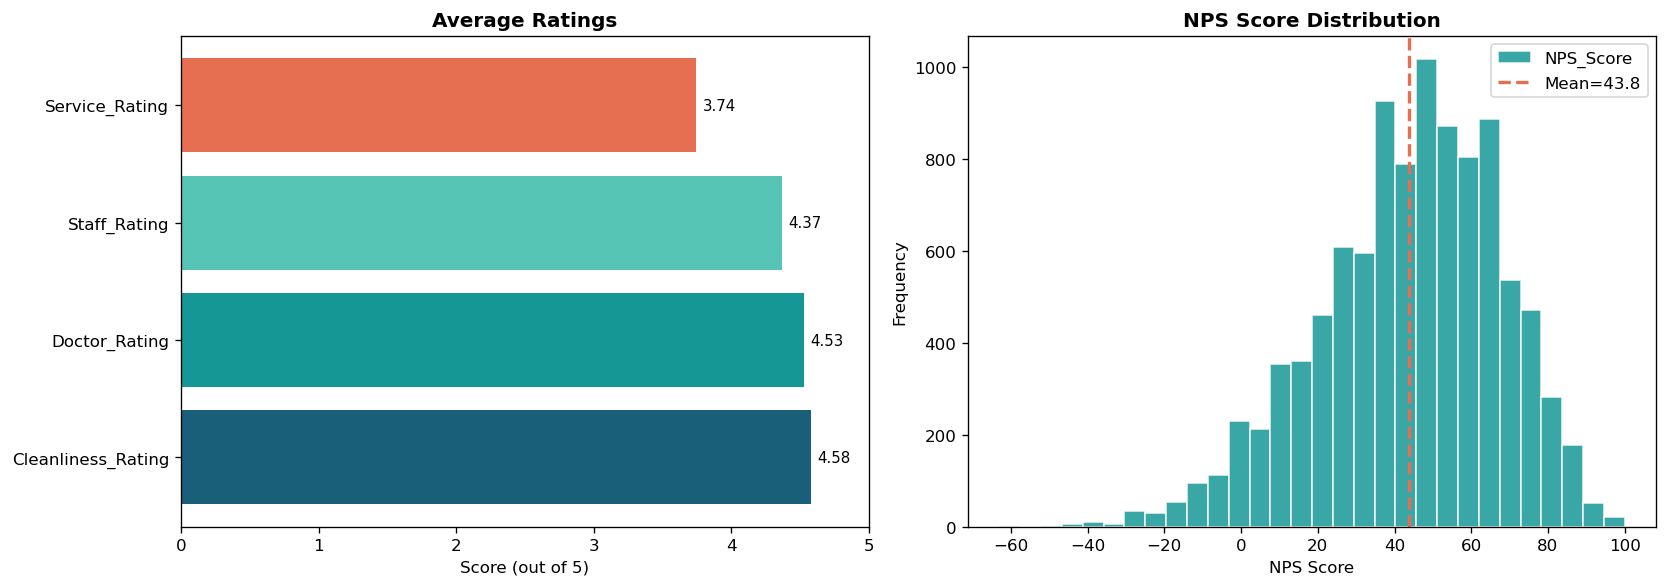

In [16]:
# ── Average Ratings Overview ──────────────────────────────────────────────
rating_cols = [c for c in ['Service_Rating','Doctor_Rating',
               'Cleanliness_Rating','Staff_Rating'] if c in df_clean.columns]
avg_ratings = df_clean[rating_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(avg_ratings.index, avg_ratings.values,
             color=['#1A5F7A','#159895','#57C5B6','#E76F51'])
axes[0].set_xlim(0, 5)
axes[0].set_title('Average Ratings', fontweight='bold')
axes[0].set_xlabel('Score (out of 5)')
for i, v in enumerate(avg_ratings.values):
    axes[0].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=9)

if 'NPS_Score' in df_clean.columns:
    df_clean['NPS_Score'].plot.hist(bins=30, color='#159895', edgecolor='white', ax=axes[1], alpha=0.85)
    axes[1].axvline(df_clean['NPS_Score'].mean(), color='#E76F51', linestyle='--',
                    linewidth=2, label=f"Mean={df_clean['NPS_Score'].mean():.1f}")
    axes[1].set_title('NPS Score Distribution', fontweight='bold')
    axes[1].set_xlabel('NPS Score')
    axes[1].legend()

plt.tight_layout()
plt.show()

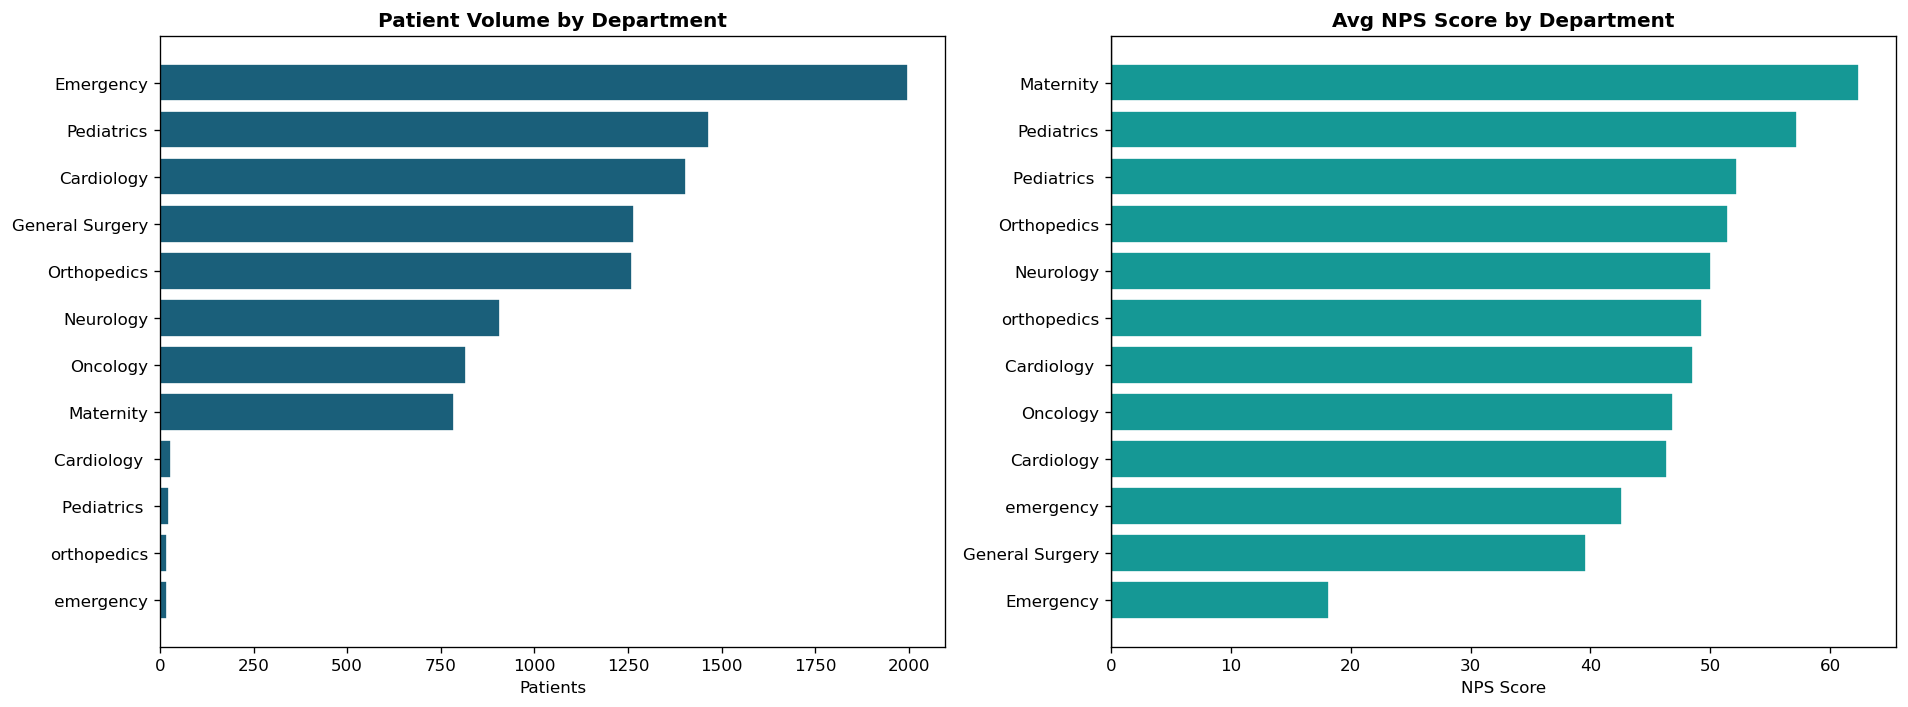

In [17]:
# ── Department Analysis ───────────────────────────────────────────────────
if 'Department' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    dep_vol = df_clean['Department'].value_counts().head(12)
    axes[0].barh(dep_vol.index[::-1], dep_vol.values[::-1], color='#1A5F7A', edgecolor='white')
    axes[0].set_title('Patient Volume by Department', fontweight='bold')
    axes[0].set_xlabel('Patients')

    if 'NPS_Score' in df_clean.columns:
        nps_dep = df_clean.groupby('Department')['NPS_Score'].mean().sort_values(ascending=False).head(12)
        colors = ['#159895' if v >= 0 else '#E76F51' for v in nps_dep.values]
        axes[1].barh(nps_dep.index[::-1], nps_dep.values[::-1], color=colors[::-1], edgecolor='white')
        axes[1].axvline(0, color='black', linewidth=0.8)
        axes[1].set_title('Avg NPS Score by Department', fontweight='bold')
        axes[1].set_xlabel('NPS Score')

    plt.tight_layout()
    plt.show()

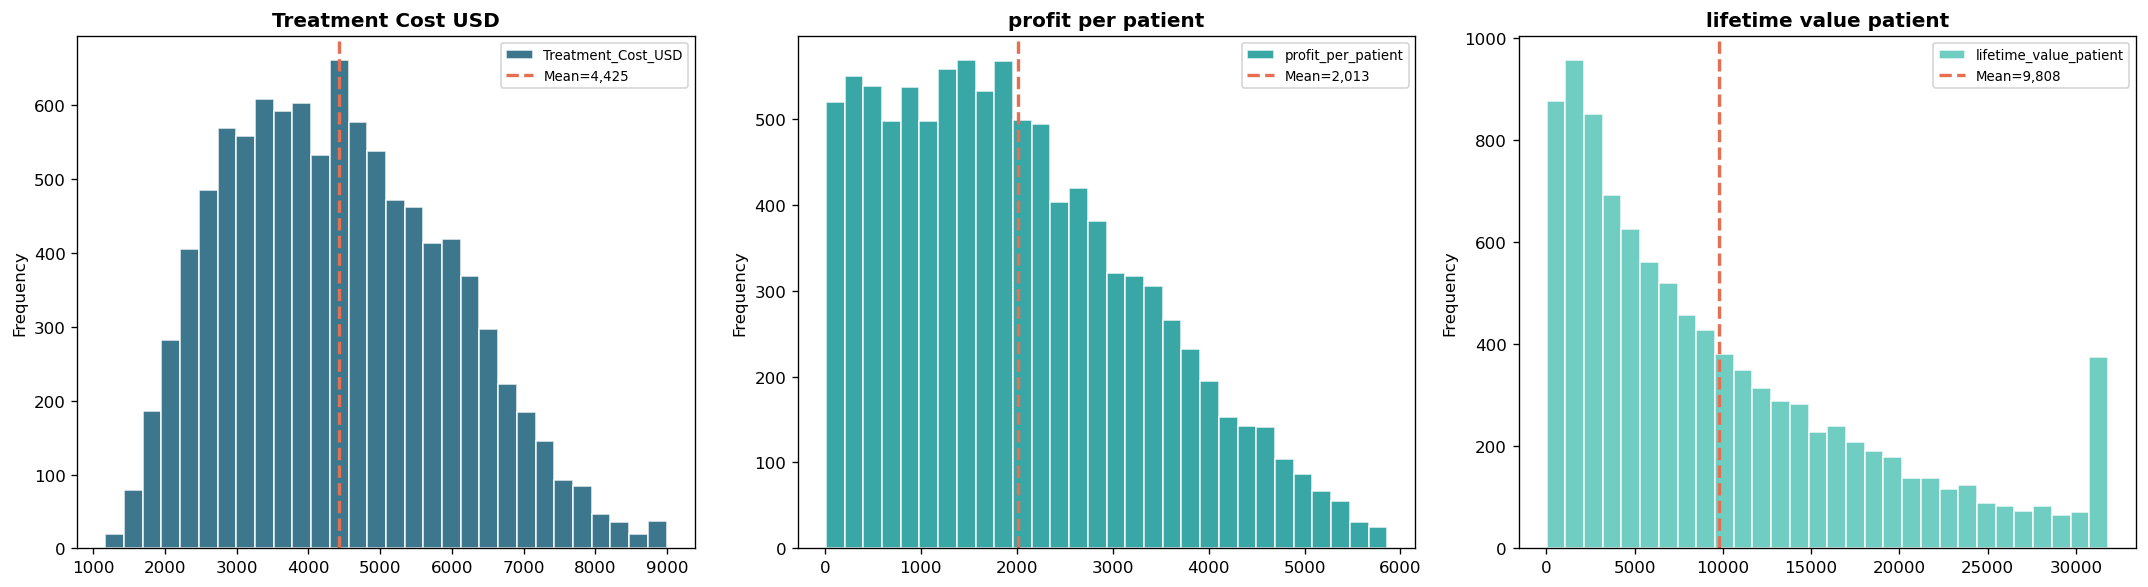


Avg Profit per Patient Segment:
patient_segment
Regular      2018.81
Insurance    2016.83
VIP          1968.43


In [18]:
# ── Financial Analysis ────────────────────────────────────────────────────
fin_cols = [c for c in ['Treatment_Cost_USD','profit_per_patient','lifetime_value_patient'] if c in df_clean.columns]

if fin_cols:
    fig, axes = plt.subplots(1, len(fin_cols), figsize=(6*len(fin_cols), 5))
    if len(fin_cols) == 1: axes = [axes]
    colors_f = ['#1A5F7A','#159895','#57C5B6']
    for ax, col, color in zip(axes, fin_cols, colors_f):
        df_clean[col].plot.hist(bins=30, color=color, edgecolor='white', ax=ax, alpha=0.85)
        ax.axvline(df_clean[col].mean(), color='#E76F51', linestyle='--',
                   linewidth=2, label=f'Mean={df_clean[col].mean():,.0f}')
        ax.set_title(col.replace('_',' '), fontweight='bold')
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    if 'patient_segment' in df_clean.columns and 'profit_per_patient' in df_clean.columns:
        seg_profit = df_clean.groupby('patient_segment')['profit_per_patient'].mean().sort_values(ascending=False)
        print('\nAvg Profit per Patient Segment:')
        print(seg_profit.round(2).to_string())

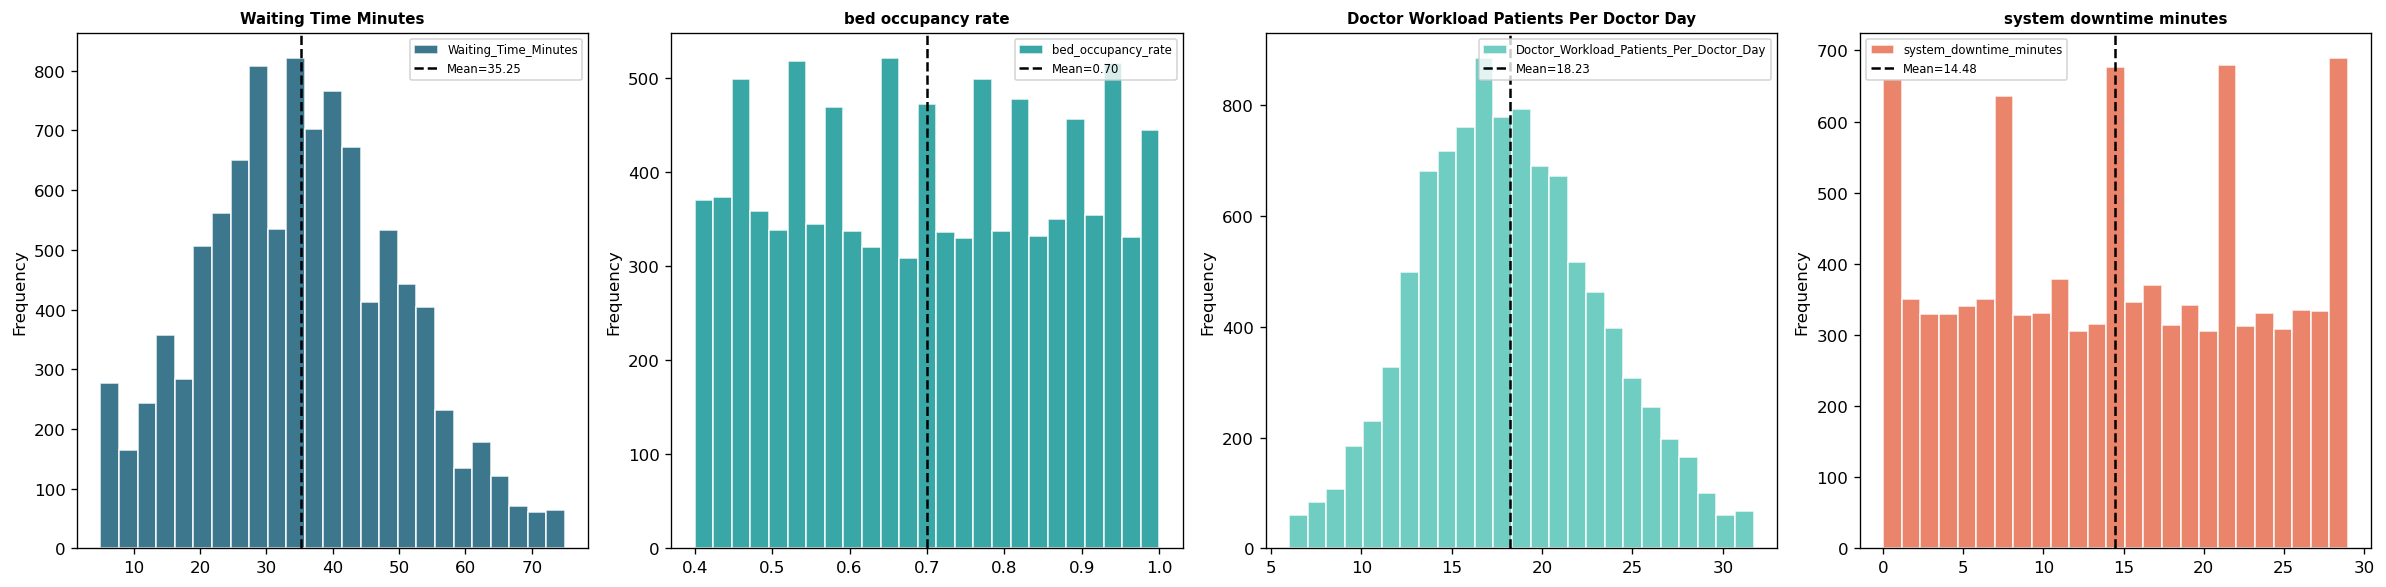

In [19]:
# ── Operational Metrics ───────────────────────────────────────────────────
ops_cols = [c for c in ['Waiting_Time_Minutes','bed_occupancy_rate',
            'Doctor_Workload_Patients_Per_Doctor_Day','system_downtime_minutes'] if c in df_clean.columns]

if ops_cols:
    fig, axes = plt.subplots(1, len(ops_cols), figsize=(5*len(ops_cols), 5))
    if len(ops_cols) == 1: axes = [axes]
    colors_ops = ['#1A5F7A','#159895','#57C5B6','#E76F51']
    for ax, col, color in zip(axes, ops_cols, colors_ops):
        df_clean[col].plot.hist(bins=25, color=color, edgecolor='white', ax=ax, alpha=0.85)
        ax.axvline(df_clean[col].mean(), color='black', linestyle='--',
                   linewidth=1.5, label=f'Mean={df_clean[col].mean():.2f}')
        ax.set_title(col.replace('_',' '), fontweight='bold', fontsize=9)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

Overall Treatment Success Rate: 0.0%


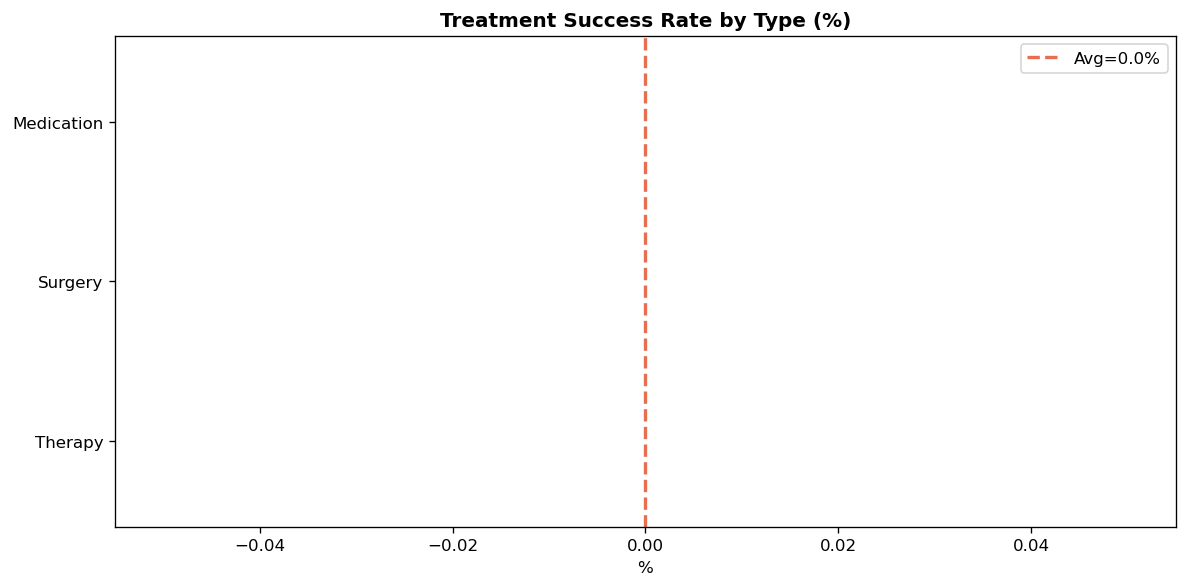


30-Day Readmission Rate:
readmission_30_days
No     80.2
Yes    19.8


In [20]:
# ── Treatment Success & Readmission ──────────────────────────────────────
if 'treatment_success' in df_clean.columns:
    success_rate = (df_clean['treatment_success'] == 'Yes').mean() * 100
    print(f'Overall Treatment Success Rate: {success_rate:.1f}%')

    if 'treatment_type' in df_clean.columns:
        ts_by_type = df_clean.groupby('treatment_type')['treatment_success'].apply(
            lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(ts_by_type.index[::-1], ts_by_type.values[::-1], color='#159895', edgecolor='white')
        ax.axvline(ts_by_type.mean(), color='#E76F51', linestyle='--', linewidth=2,
                   label=f'Avg={ts_by_type.mean():.1f}%')
        ax.set_title('Treatment Success Rate by Type (%)', fontweight='bold')
        ax.set_xlabel('%')
        ax.legend()
        plt.tight_layout()
        plt.show()

if 'readmission_30_days' in df_clean.columns:
    ra = df_clean['readmission_30_days'].value_counts(normalize=True) * 100
    print(f'\n30-Day Readmission Rate:')
    print(ra.round(1).to_string())

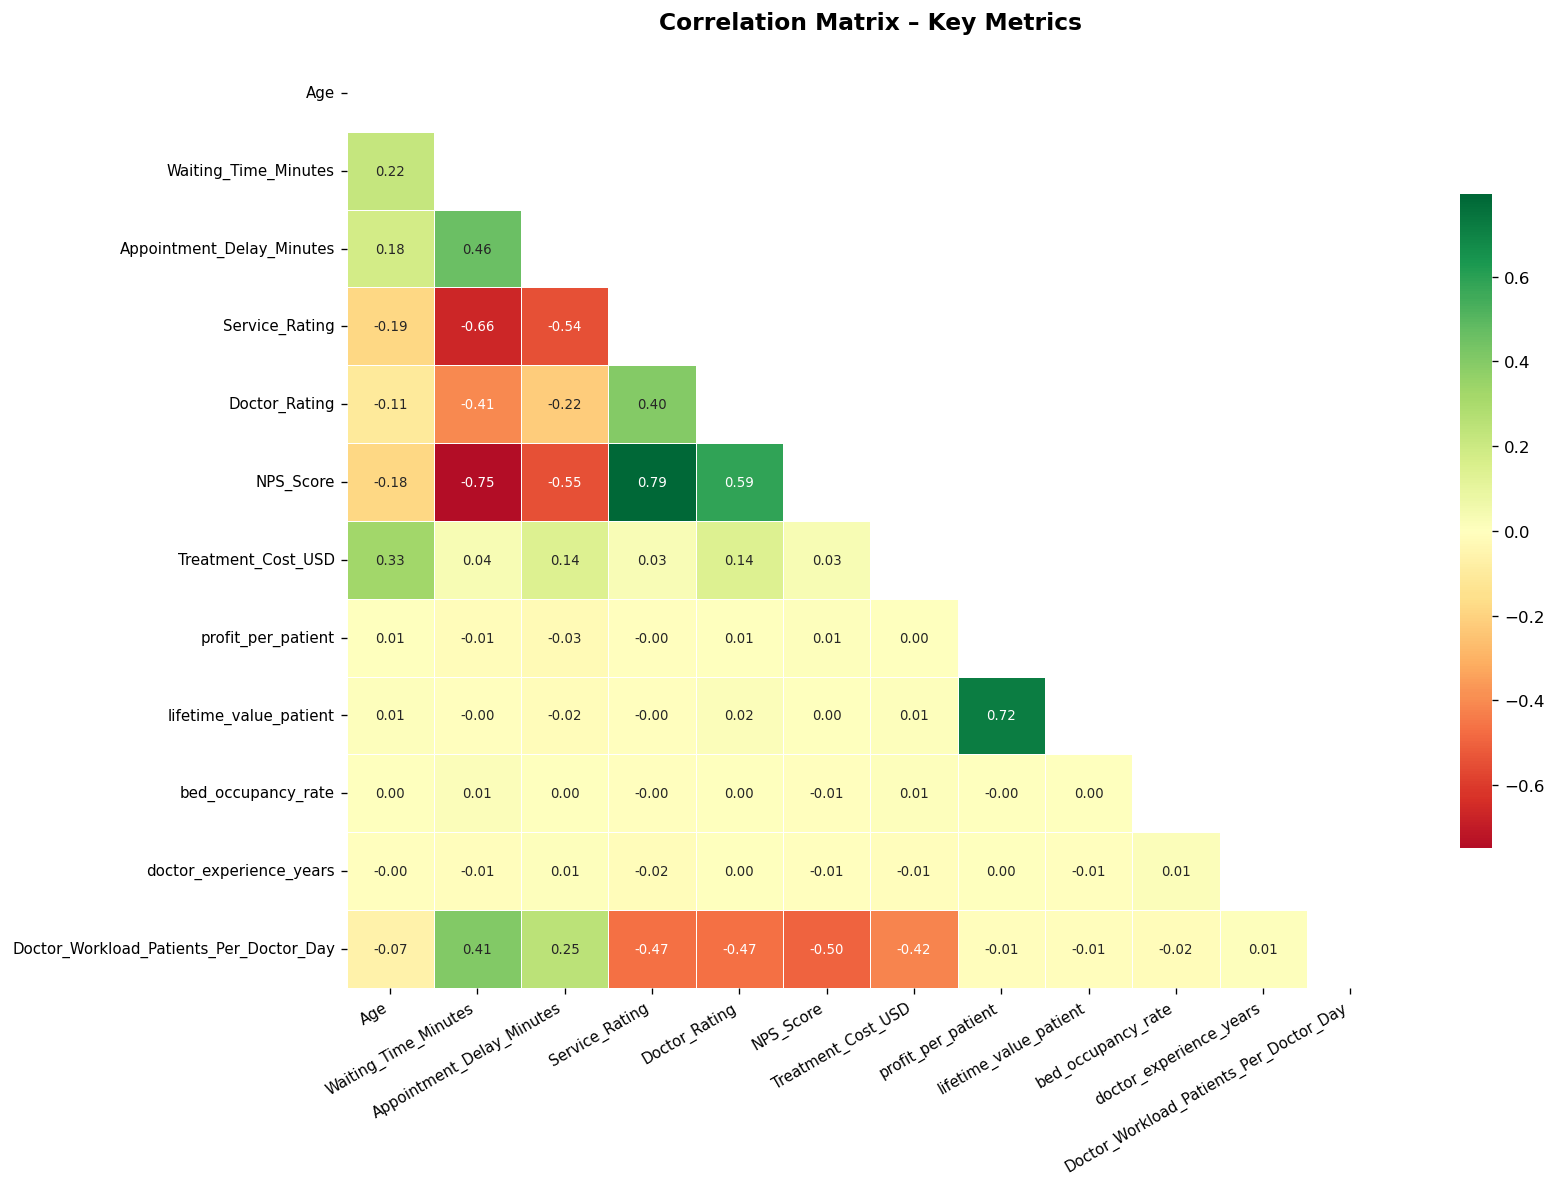

In [21]:
# ── Correlation Analysis ──────────────────────────────────────────────────
key_corr_cols = [
    'Age','Waiting_Time_Minutes','Appointment_Delay_Minutes',
    'Service_Rating','Doctor_Rating','NPS_Score',
    'Treatment_Cost_USD','profit_per_patient','lifetime_value_patient',
    'bed_occupancy_rate','doctor_experience_years',
    'Doctor_Workload_Patients_Per_Doctor_Day'
]
key_corr_cols = [c for c in key_corr_cols if c in df_clean.columns]
corr = df_clean[key_corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix – Key Metrics', fontweight='bold', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## ⑦ Dashboard (5 Pages)
Each page is saved as a PNG and also displayed inline.

In [22]:
# ── Colour Palette & Global Style ─────────────────────────────────────────
BLUE   = '#1A5F7A'
TEAL   = '#159895'
MINT   = '#57C5B6'
SAND   = '#F0EBD8'
ACCENT = '#E76F51'
LIGHT  = '#EEF7FF'
DARK   = '#0D2137'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.facecolor': LIGHT,
    'figure.facecolor': SAND,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.titlecolor': DARK,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})
print('✅ Palette set')

✅ Palette set


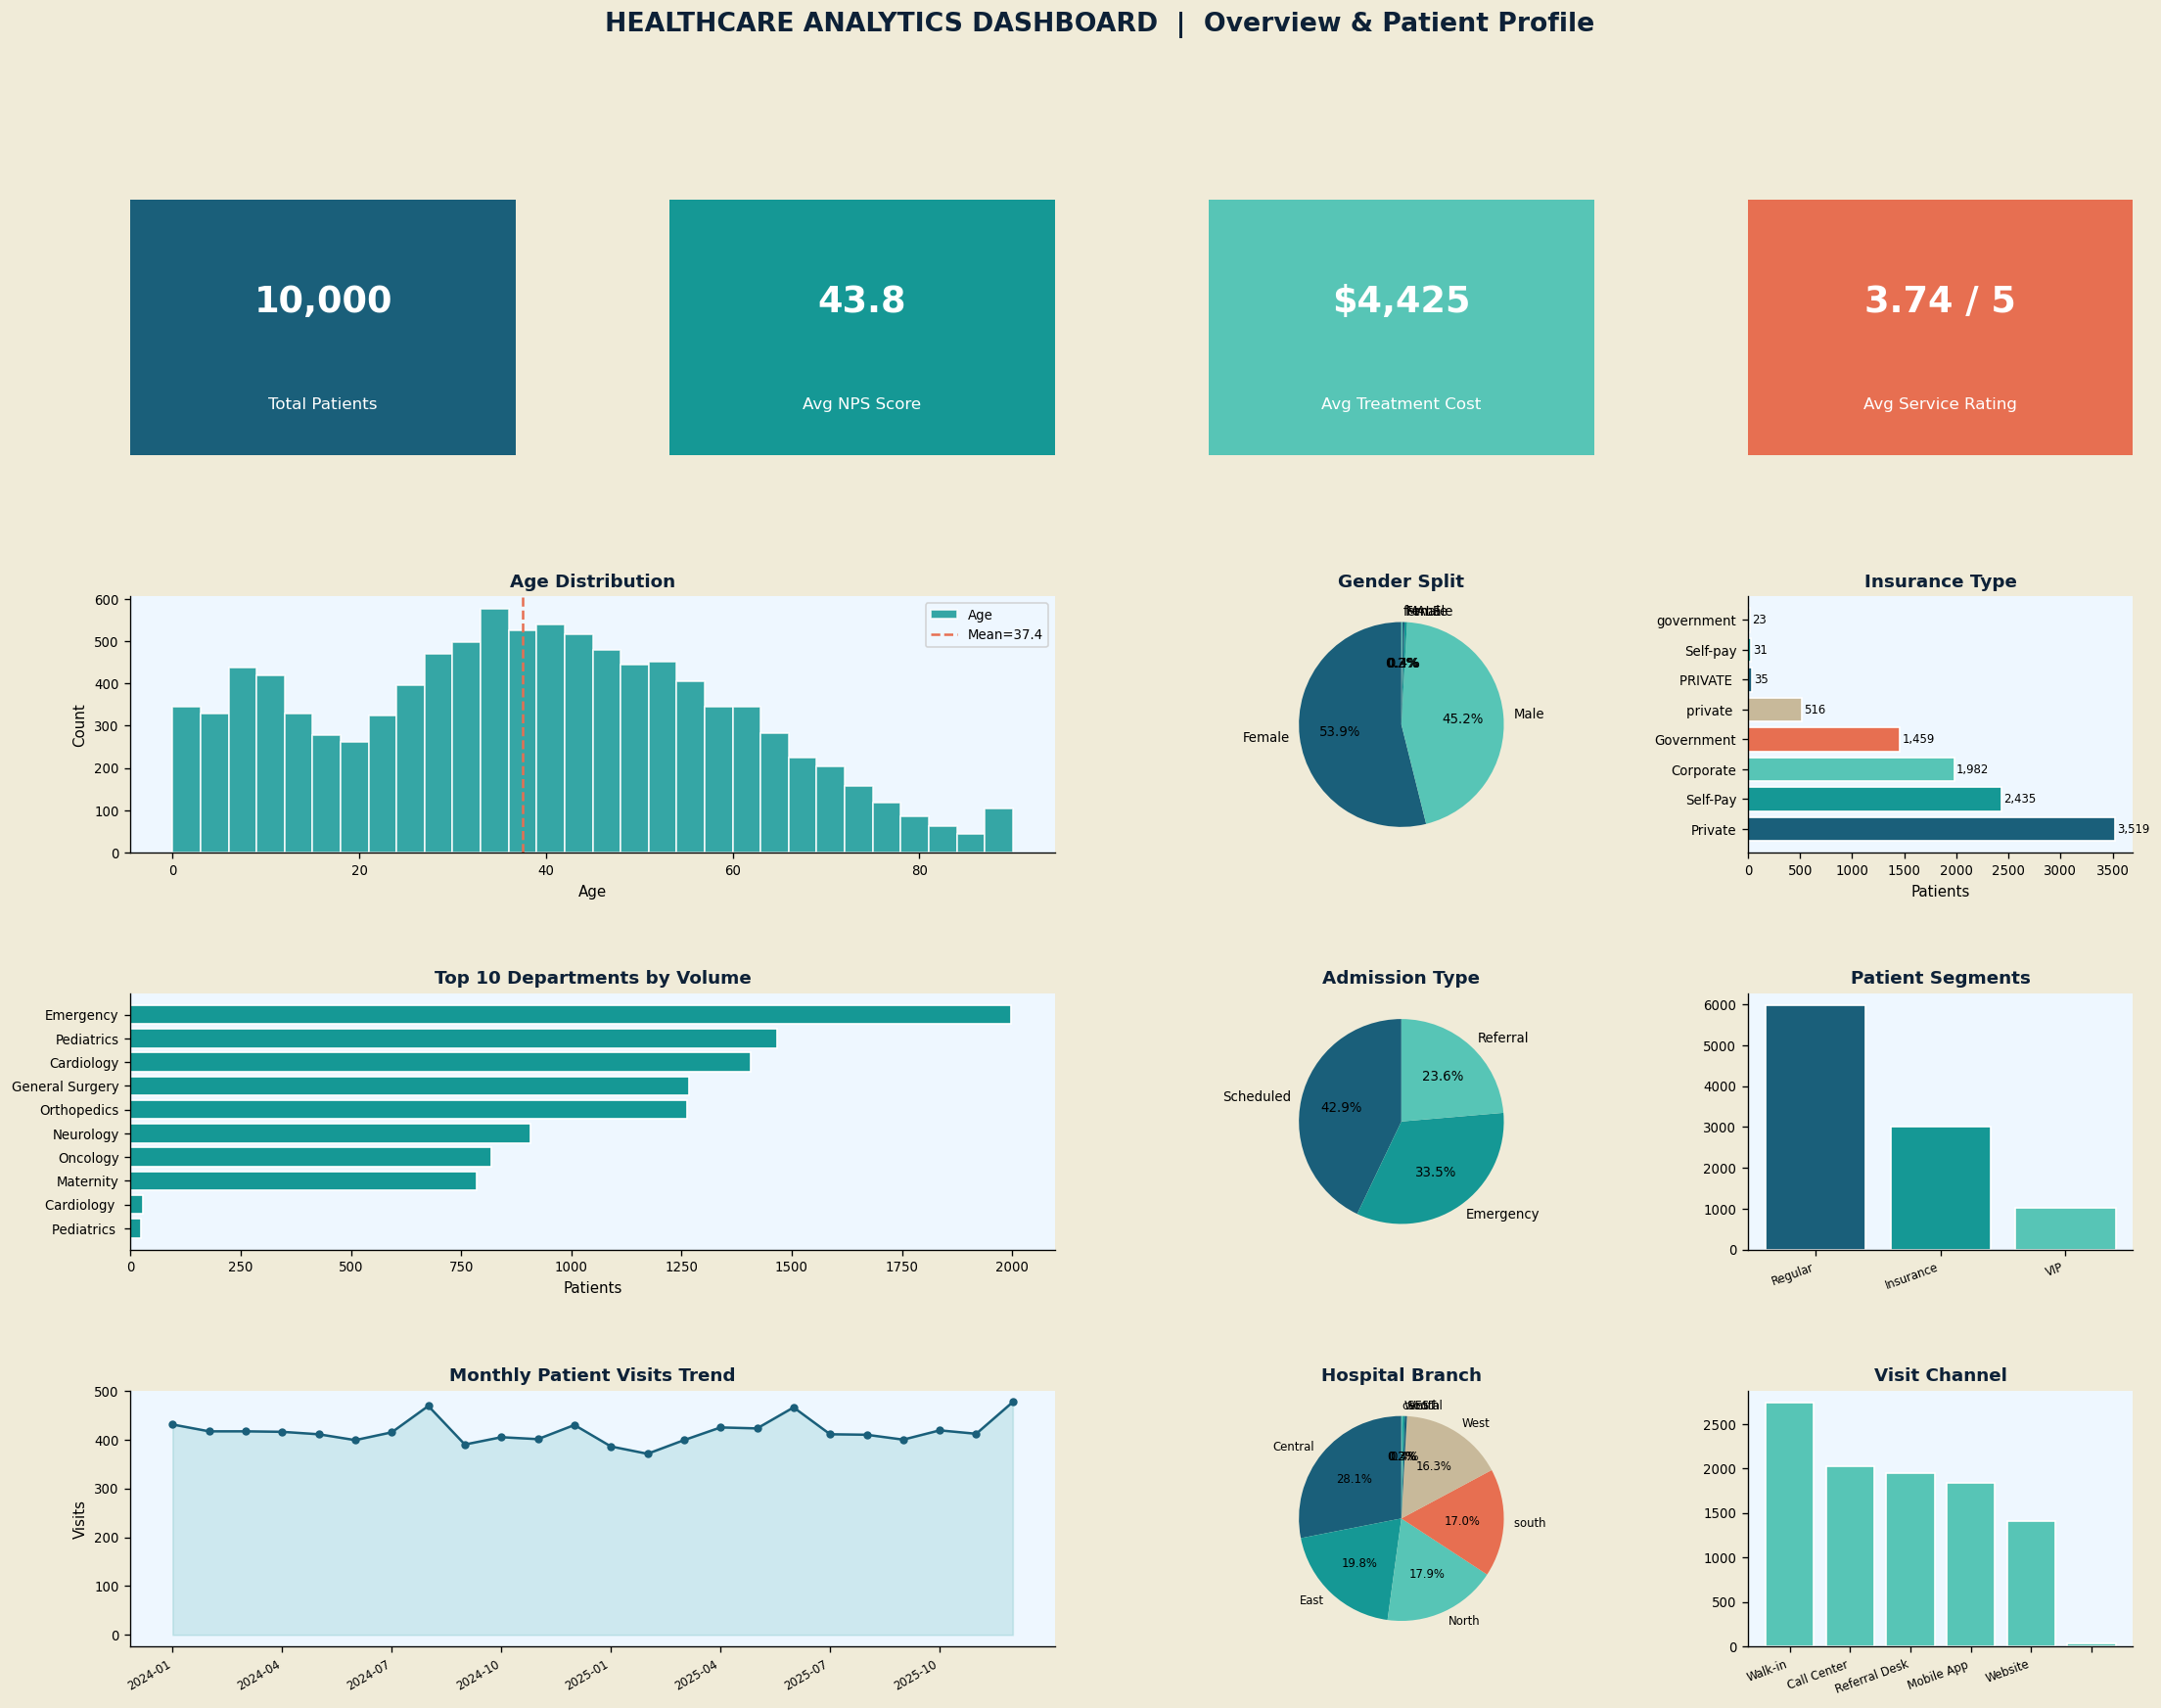

✅ Page 1 saved as dashboard_page1.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════
# PAGE 1 – OVERVIEW & PATIENT PROFILE
# ══════════════════════════════════════════════════════════════════════════
fig1 = plt.figure(figsize=(22, 16))
fig1.patch.set_facecolor(SAND)
gs = gridspec.GridSpec(4, 4, figure=fig1, hspace=0.55, wspace=0.40)

# KPI Banner
kpis = [
    ('Total Patients',     f"{len(df_clean):,}",                    BLUE),
    ('Avg NPS Score',      f"{df_clean['NPS_Score'].mean():.1f}" if 'NPS_Score' in df_clean.columns else 'N/A', TEAL),
    ('Avg Treatment Cost', f"${df_clean['Treatment_Cost_USD'].mean():,.0f}" if 'Treatment_Cost_USD' in df_clean.columns else 'N/A', MINT),
    ('Avg Service Rating', f"{df_clean['Service_Rating'].mean():.2f} / 5" if 'Service_Rating' in df_clean.columns else 'N/A', ACCENT),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig1.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, val,   ha='center', va='center', fontsize=22,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=10,
            color='white', transform=ax.transAxes)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

# Age Distribution
ax = fig1.add_subplot(gs[1, :2])
df_clean['Age'].plot.hist(bins=30, color=TEAL, edgecolor='white', ax=ax, alpha=0.85)
ax.axvline(df_clean['Age'].mean(), color=ACCENT, linestyle='--', linewidth=1.5,
           label=f"Mean={df_clean['Age'].mean():.1f}")
ax.set_title('Age Distribution'); ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.legend(fontsize=8)

# Gender Pie
ax = fig1.add_subplot(gs[1, 2])
if 'Gender' in df_clean.columns:
    g = df_clean['Gender'].value_counts()
    ax.pie(g, labels=g.index, autopct='%1.1f%%', colors=[BLUE, MINT, TEAL],
           startangle=90, textprops={'fontsize': 8})
ax.set_title('Gender Split')

# Insurance Type
ax = fig1.add_subplot(gs[1, 3])
if 'Insurance_Type' in df_clean.columns:
    ins = df_clean['Insurance_Type'].value_counts()
    bars = ax.barh(ins.index, ins.values,
                   color=[BLUE, TEAL, MINT, ACCENT, '#C8B99A'][:len(ins)], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=7)
ax.set_title('Insurance Type'); ax.set_xlabel('Patients')

# Department Volume
ax = fig1.add_subplot(gs[2, :2])
if 'Department' in df_clean.columns:
    dep = df_clean['Department'].value_counts().head(10)
    ax.barh(dep.index[::-1], dep.values[::-1], color=TEAL, edgecolor='white')
ax.set_title('Top 10 Departments by Volume'); ax.set_xlabel('Patients')

# Admission Type
ax = fig1.add_subplot(gs[2, 2])
if 'Admission_Type' in df_clean.columns:
    adm = df_clean['Admission_Type'].value_counts()
    ax.pie(adm, labels=adm.index, autopct='%1.1f%%',
           colors=[BLUE, TEAL, MINT, ACCENT], startangle=90, textprops={'fontsize': 8})
ax.set_title('Admission Type')

# Patient Segment
ax = fig1.add_subplot(gs[2, 3])
if 'patient_segment' in df_clean.columns:
    seg = df_clean['patient_segment'].value_counts()
    ax.bar(seg.index, seg.values, color=[BLUE, TEAL, MINT, ACCENT][:len(seg)], edgecolor='white')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)
ax.set_title('Patient Segments')

# Monthly Visits Trend
ax = fig1.add_subplot(gs[3, :2])
if 'Survey_Date' in df_clean.columns:
    monthly = df_clean.groupby(df_clean['Survey_Date'].dt.to_period('M')).size().reset_index(name='count')
    monthly['Survey_Date'] = monthly['Survey_Date'].astype(str)
    ax.plot(range(len(monthly)), monthly['count'], color=BLUE, marker='o', markersize=4)
    ax.fill_between(range(len(monthly)), monthly['count'], alpha=0.15, color=TEAL)
    step = max(1, len(monthly)//8)
    ax.set_xticks(range(0, len(monthly), step))
    ax.set_xticklabels(monthly['Survey_Date'].iloc[::step], rotation=30, ha='right', fontsize=7)
ax.set_title('Monthly Patient Visits Trend'); ax.set_ylabel('Visits')

# Hospital Branch
ax = fig1.add_subplot(gs[3, 2])
if 'Hospital_Branch' in df_clean.columns:
    br = df_clean['Hospital_Branch'].value_counts()
    ax.pie(br, labels=br.index, autopct='%1.1f%%',
           colors=[BLUE,TEAL,MINT,ACCENT,'#C8B99A'][:len(br)],
           startangle=90, textprops={'fontsize': 7})
ax.set_title('Hospital Branch')

# Visit Channel
ax = fig1.add_subplot(gs[3, 3])
if 'Visit_Channel' in df_clean.columns:
    vc = df_clean['Visit_Channel'].value_counts()
    ax.bar(vc.index, vc.values, color=MINT, edgecolor='white')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)
ax.set_title('Visit Channel')

fig1.suptitle('HEALTHCARE ANALYTICS DASHBOARD  |  Overview & Patient Profile',
              fontsize=16, fontweight='bold', color=DARK, y=0.98)
plt.savefig('dashboard_page1.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Page 1 saved as dashboard_page1.png')

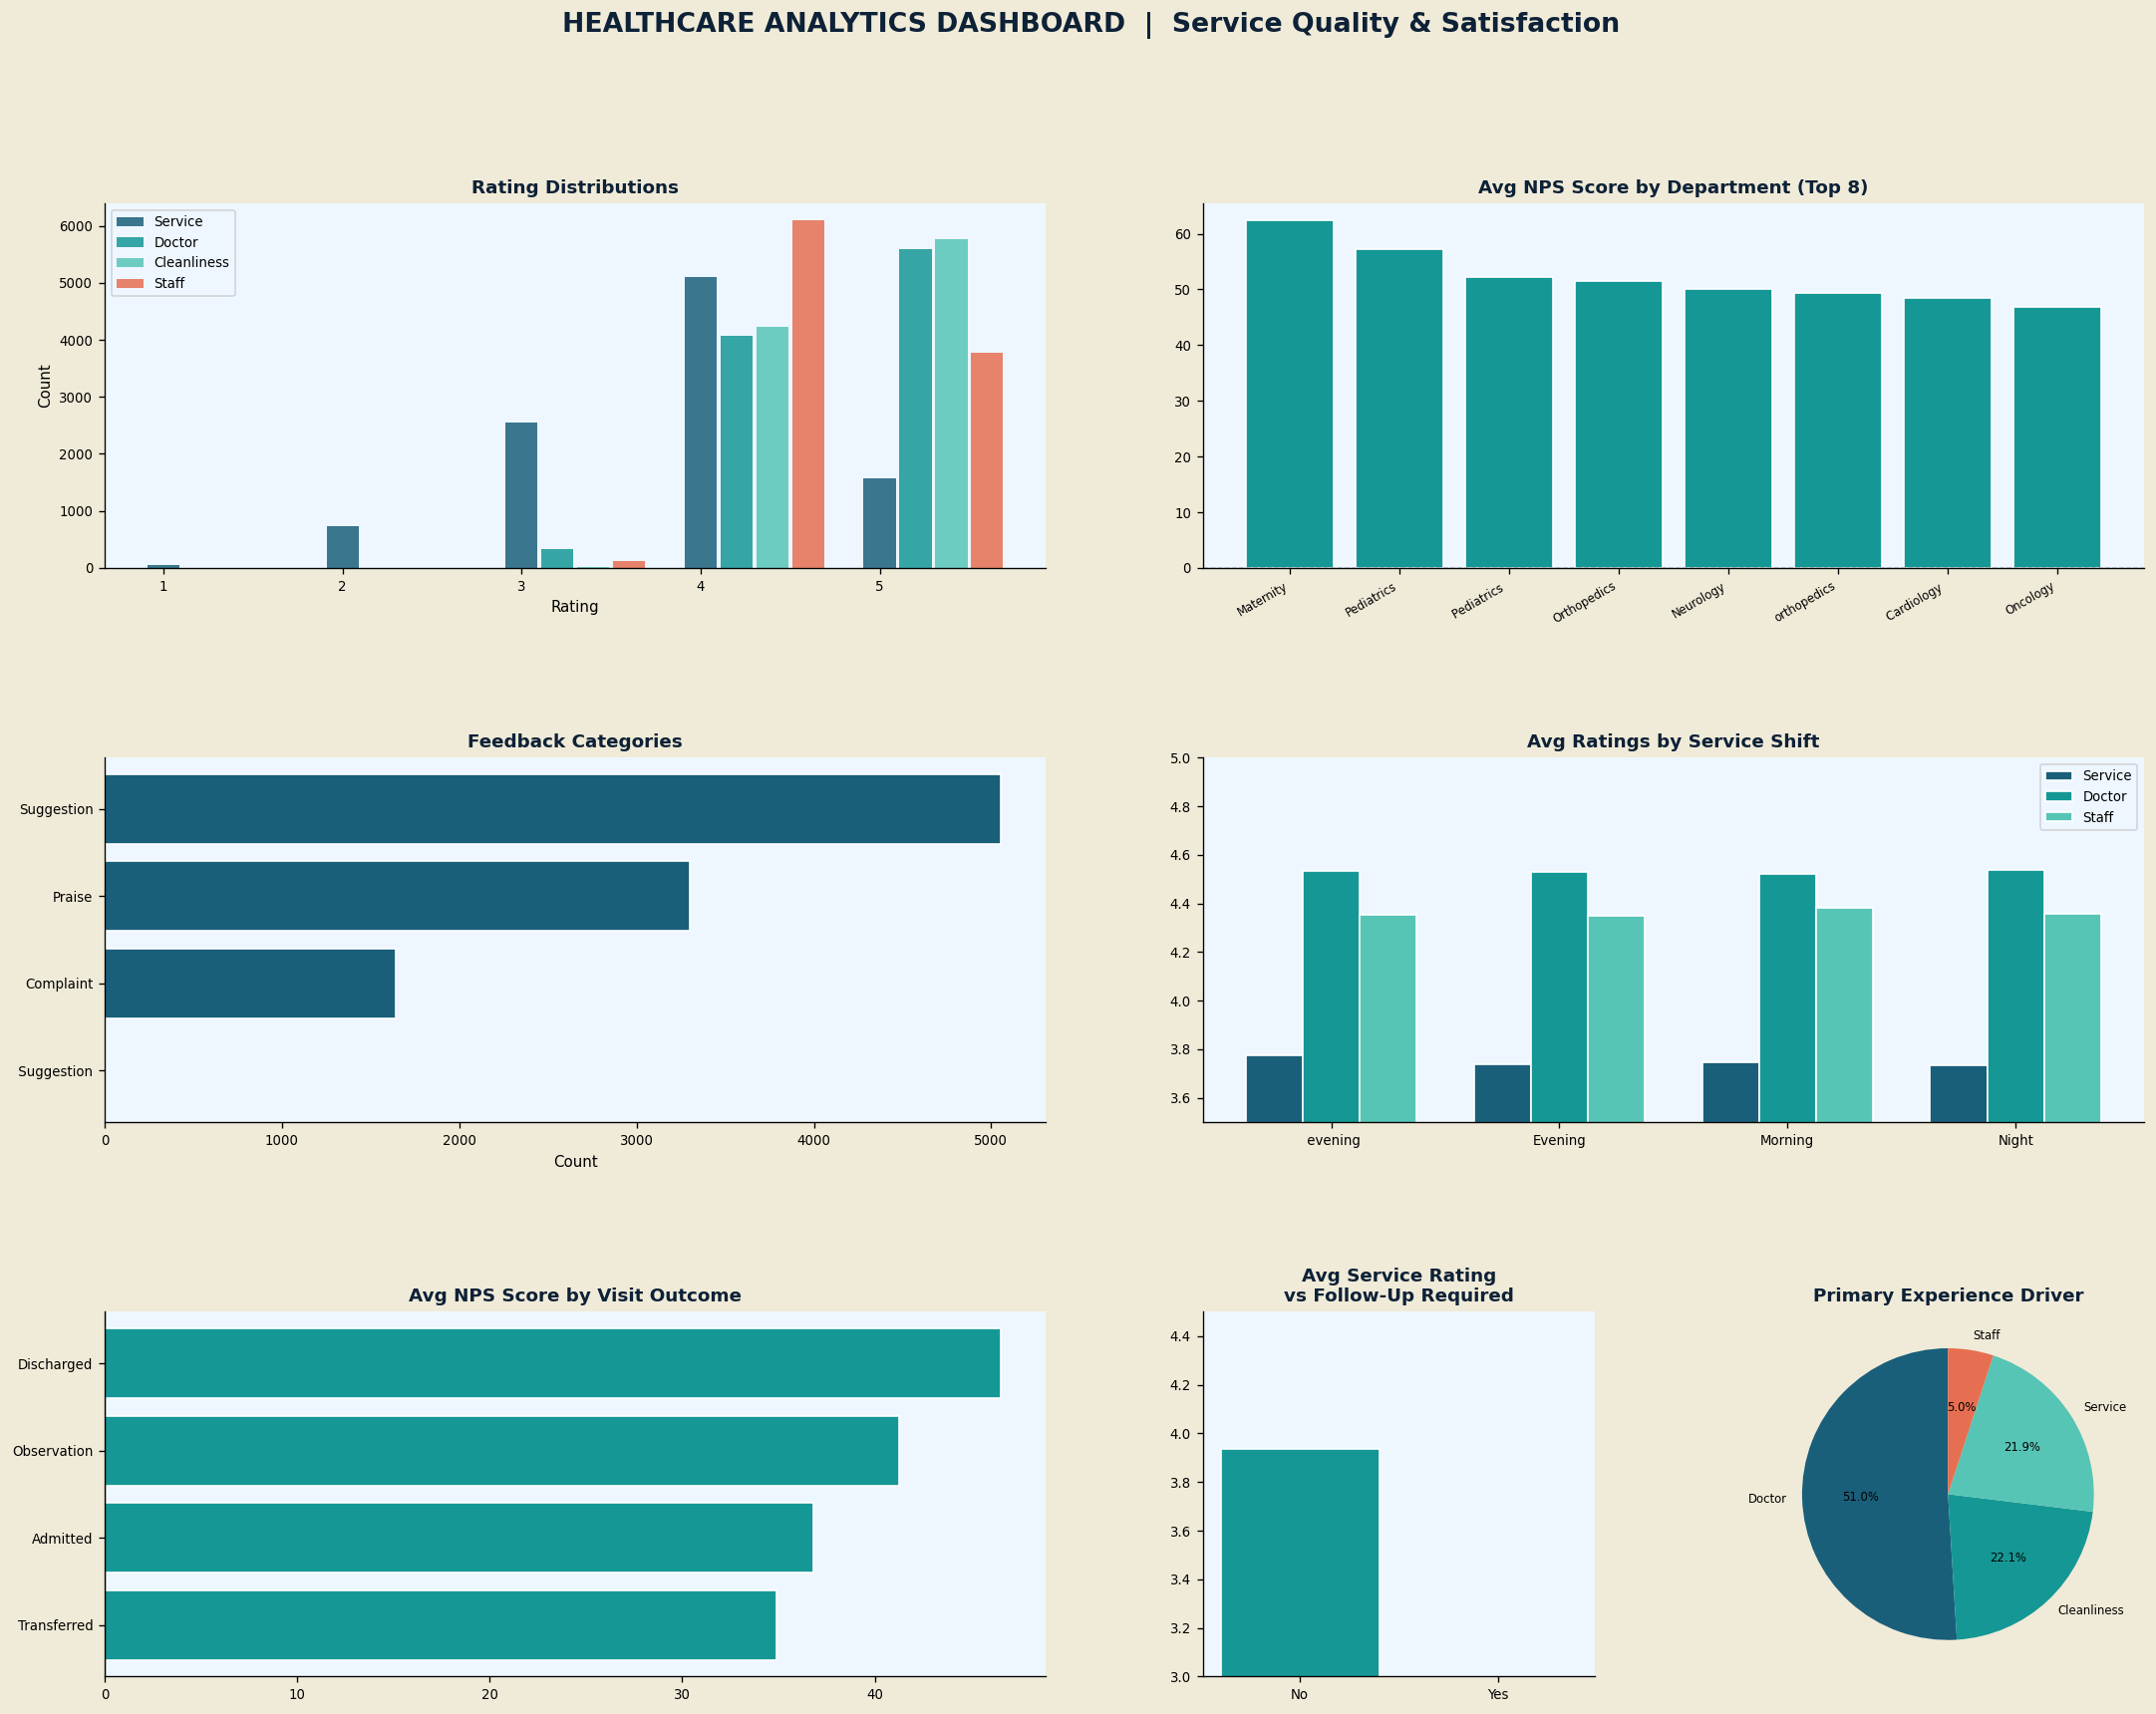

✅ Page 2 saved as dashboard_page2.png


In [24]:
# ══════════════════════════════════════════════════════════════════════════
# PAGE 2 – SERVICE QUALITY & SATISFACTION
# ══════════════════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 16))
fig2.patch.set_facecolor(SAND)
gs2 = gridspec.GridSpec(3, 4, figure=fig2, hspace=0.52, wspace=0.40)

# Rating Distributions
ax = fig2.add_subplot(gs2[0, :2])
rating_cols = [c for c in ['Service_Rating','Doctor_Rating','Cleanliness_Rating','Staff_Rating'] if c in df_clean.columns]
colors_r = [BLUE, TEAL, MINT, ACCENT]
for col, col_color in zip(rating_cols, colors_r):
    vals = df_clean[col].value_counts().sort_index()
    offset = rating_cols.index(col) * 0.2
    ax.bar([x + offset for x in vals.index], vals.values,
           width=0.18, color=col_color, label=col.replace('_Rating',''), alpha=0.85)
ax.set_title('Rating Distributions'); ax.set_xlabel('Rating'); ax.set_ylabel('Count')
ax.legend(fontsize=8); ax.set_xticks([1,2,3,4,5])

# NPS by Department
ax = fig2.add_subplot(gs2[0, 2:])
if 'Department' in df_clean.columns and 'NPS_Score' in df_clean.columns:
    nps_dep = df_clean.groupby('Department')['NPS_Score'].mean().sort_values(ascending=False).head(8)
    ax.bar(nps_dep.index, nps_dep.values,
           color=[TEAL if v > 0 else ACCENT for v in nps_dep.values], edgecolor='white')
    ax.axhline(0, color=DARK, linewidth=0.8, linestyle='--')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
ax.set_title('Avg NPS Score by Department (Top 8)')

# Feedback Category
ax = fig2.add_subplot(gs2[1, :2])
if 'Feedback_Category' in df_clean.columns:
    fb = df_clean['Feedback_Category'].value_counts()
    ax.barh(fb.index[::-1], fb.values[::-1], color=BLUE, edgecolor='white')
ax.set_title('Feedback Categories'); ax.set_xlabel('Count')

# Avg Ratings by Service Shift
ax = fig2.add_subplot(gs2[1, 2:])
if 'Service_Shift' in df_clean.columns:
    shift_cols = [c for c in ['Service_Rating','Doctor_Rating','Staff_Rating'] if c in df_clean.columns]
    shift_rat = df_clean.groupby('Service_Shift')[shift_cols].mean()
    x = np.arange(len(shift_rat)); w = 0.25
    for i, (col, color) in enumerate(zip(shift_rat.columns, [BLUE, TEAL, MINT])):
        ax.bar(x + i*w, shift_rat[col], width=w, color=color,
               label=col.replace('_Rating',''), edgecolor='white')
    ax.set_xticks(x + w); ax.set_xticklabels(shift_rat.index)
    ax.legend(fontsize=8); ax.set_ylim(3.5, 5)
ax.set_title('Avg Ratings by Service Shift')

# NPS by Visit Outcome
ax = fig2.add_subplot(gs2[2, :2])
if 'Visit_Outcome' in df_clean.columns and 'NPS_Score' in df_clean.columns:
    nps_out = df_clean.groupby('Visit_Outcome')['NPS_Score'].mean().sort_values()
    ax.barh(nps_out.index, nps_out.values,
            color=[TEAL if v > 0 else ACCENT for v in nps_out.values], edgecolor='white')
    ax.axvline(0, color=DARK, linewidth=0.8)
ax.set_title('Avg NPS Score by Visit Outcome')

# Follow-Up vs Service Rating
ax = fig2.add_subplot(gs2[2, 2])
if 'Follow_Up_Required' in df_clean.columns and 'Service_Rating' in df_clean.columns:
    fu = df_clean.groupby('Follow_Up_Required')['Service_Rating'].mean()
    ax.bar(fu.index, fu.values, color=[TEAL, ACCENT], edgecolor='white')
    ax.set_ylim(3, 4.5)
ax.set_title('Avg Service Rating\nvs Follow-Up Required')

# Primary Experience Driver
ax = fig2.add_subplot(gs2[2, 3])
if 'Primary_Experience_Driver' in df_clean.columns:
    ped = df_clean['Primary_Experience_Driver'].value_counts().head(6)
    ax.pie(ped, labels=ped.index, autopct='%1.1f%%',
           colors=[BLUE,TEAL,MINT,ACCENT,'#2EC4B6','#CBDDD1'],
           startangle=90, textprops={'fontsize': 7})
ax.set_title('Primary Experience Driver')

fig2.suptitle('HEALTHCARE ANALYTICS DASHBOARD  |  Service Quality & Satisfaction',
              fontsize=16, fontweight='bold', color=DARK, y=0.98)
plt.savefig('dashboard_page2.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Page 2 saved as dashboard_page2.png')

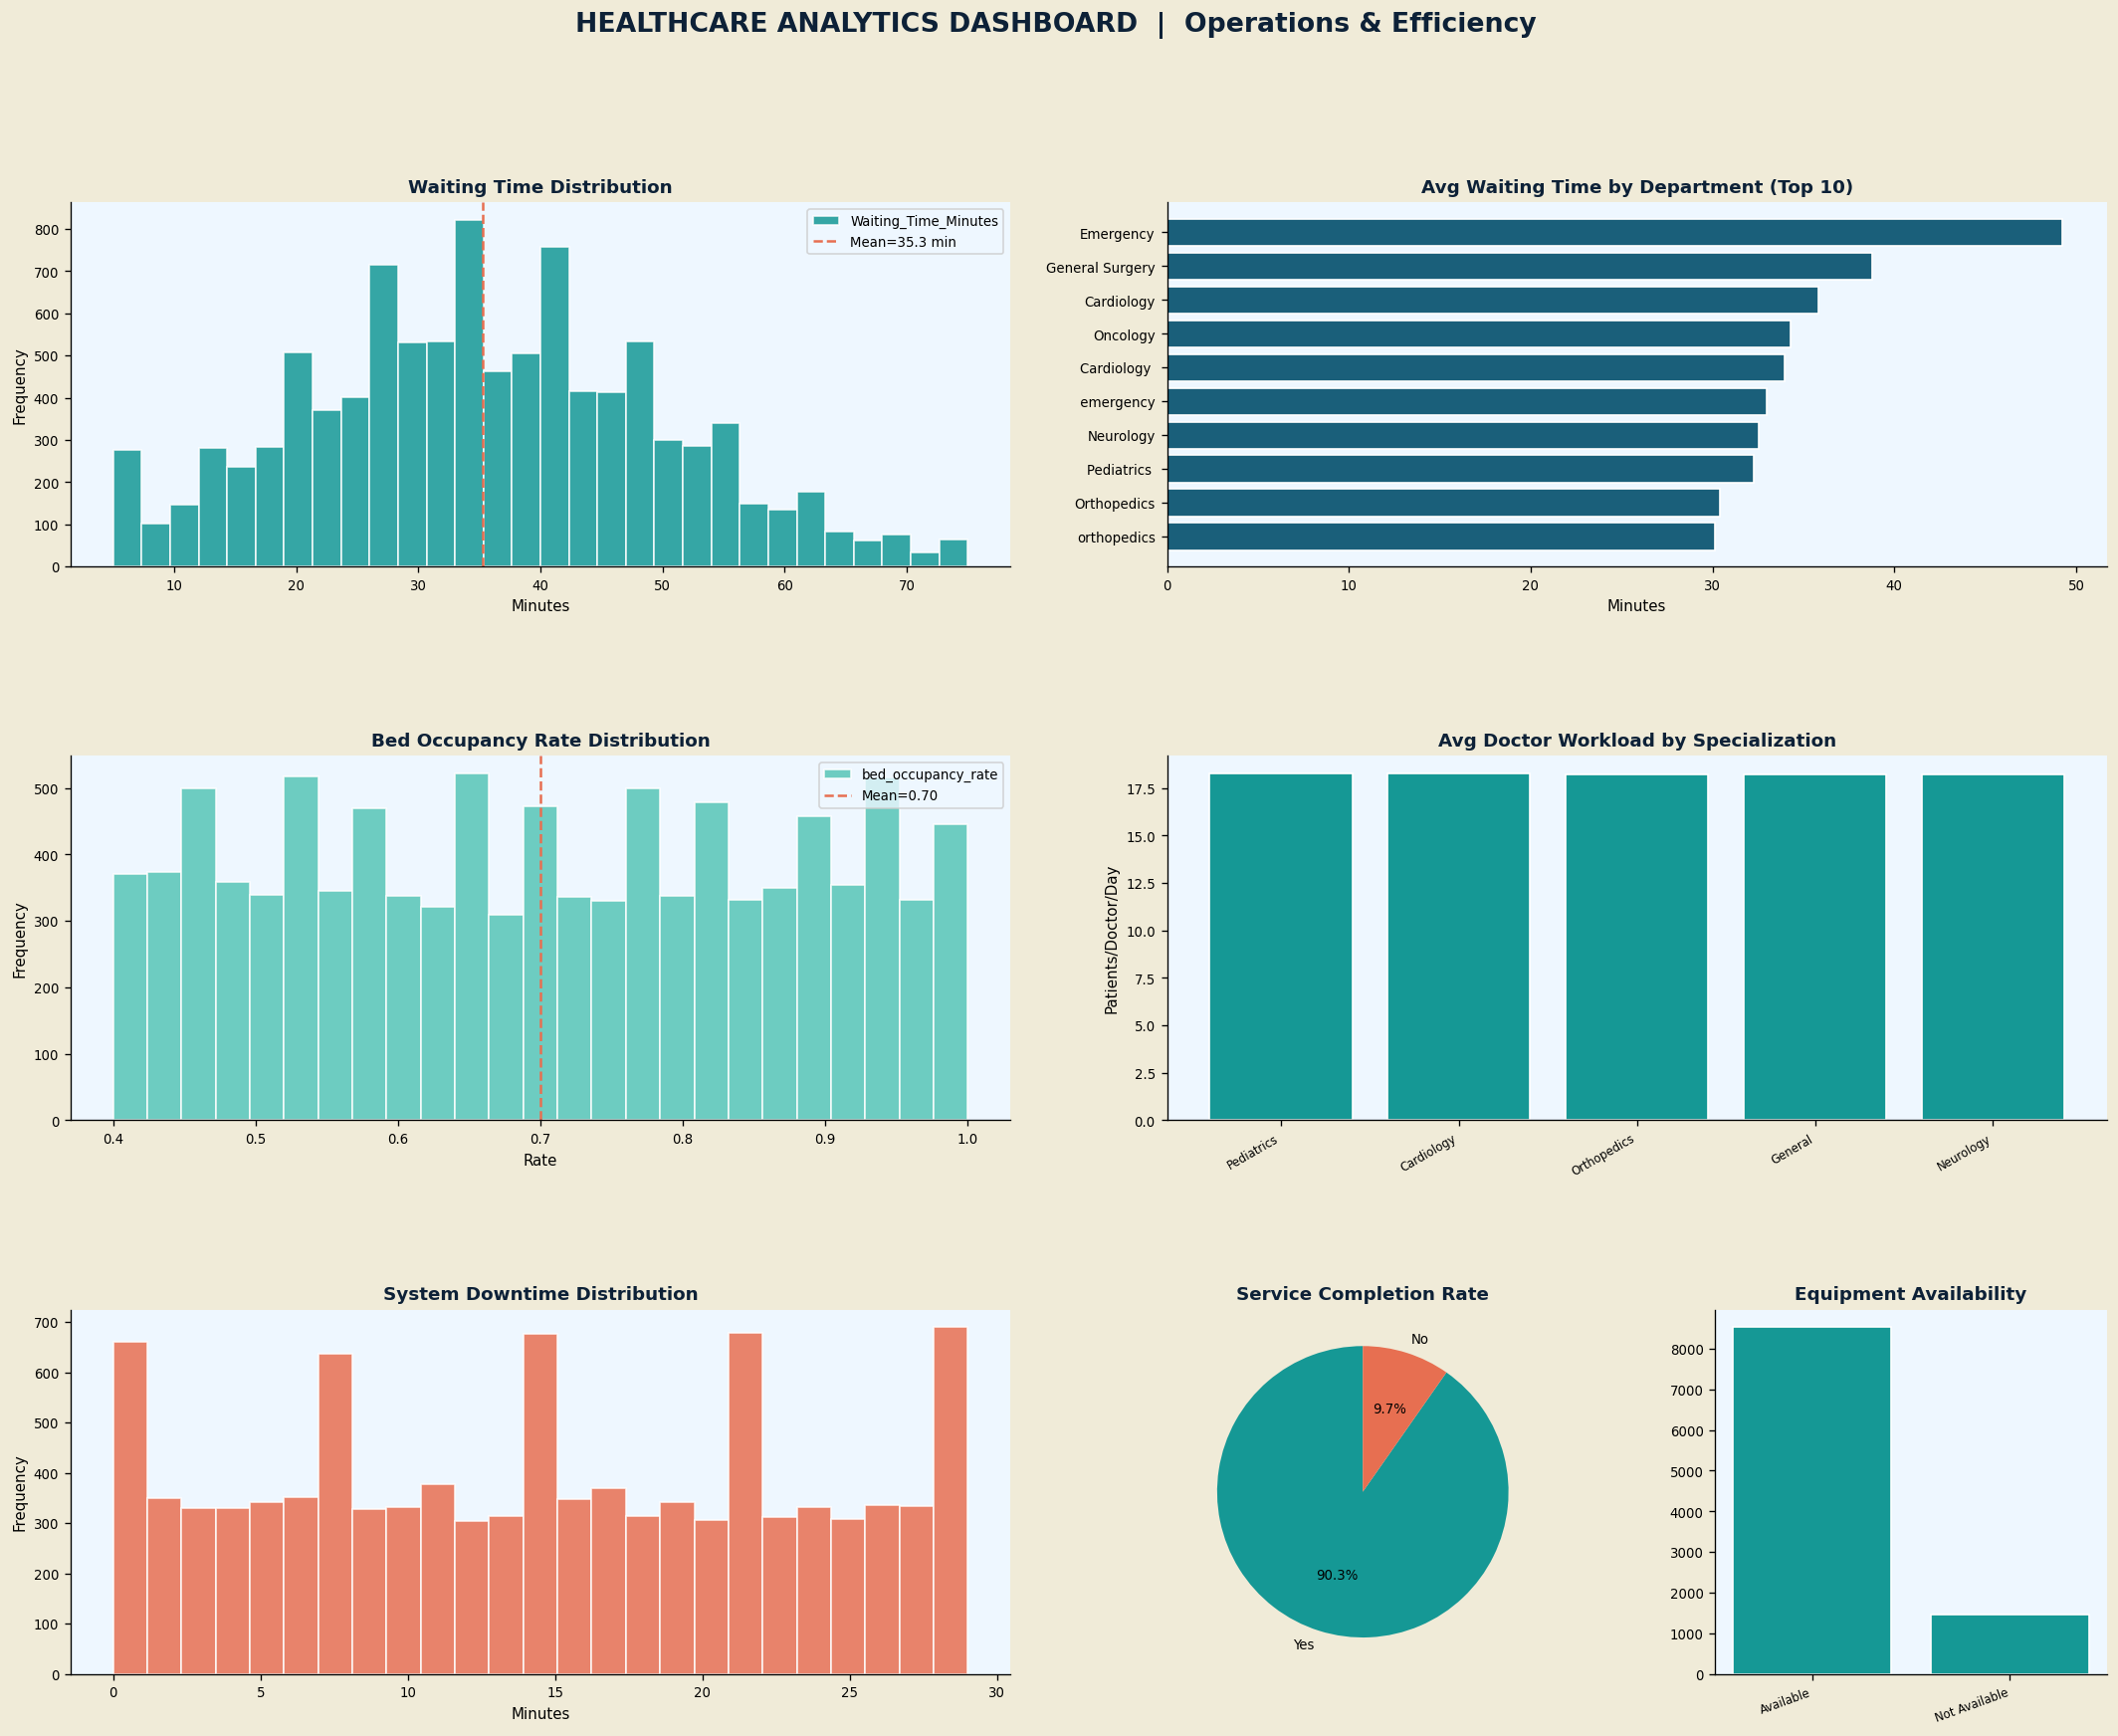

✅ Page 3 saved as dashboard_page3.png


In [25]:
# ══════════════════════════════════════════════════════════════════════════
# PAGE 3 – OPERATIONS & EFFICIENCY
# ══════════════════════════════════════════════════════════════════════════
fig3 = plt.figure(figsize=(22, 16))
fig3.patch.set_facecolor(SAND)
gs3 = gridspec.GridSpec(3, 4, figure=fig3, hspace=0.52, wspace=0.40)

# Waiting Time Distribution
ax = fig3.add_subplot(gs3[0, :2])
if 'Waiting_Time_Minutes' in df_clean.columns:
    df_clean['Waiting_Time_Minutes'].plot.hist(bins=30, color=TEAL, edgecolor='white', ax=ax, alpha=0.85)
    ax.axvline(df_clean['Waiting_Time_Minutes'].mean(), color=ACCENT, linestyle='--', linewidth=1.5,
               label=f"Mean={df_clean['Waiting_Time_Minutes'].mean():.1f} min")
    ax.legend(fontsize=8)
ax.set_title('Waiting Time Distribution'); ax.set_xlabel('Minutes')

# Avg Wait by Department
ax = fig3.add_subplot(gs3[0, 2:])
if 'Department' in df_clean.columns and 'Waiting_Time_Minutes' in df_clean.columns:
    wait_dep = df_clean.groupby('Department')['Waiting_Time_Minutes'].mean().sort_values(ascending=False).head(10)
    ax.barh(wait_dep.index[::-1], wait_dep.values[::-1], color=BLUE, edgecolor='white')
ax.set_title('Avg Waiting Time by Department (Top 10)'); ax.set_xlabel('Minutes')

# Bed Occupancy
ax = fig3.add_subplot(gs3[1, :2])
if 'bed_occupancy_rate' in df_clean.columns:
    df_clean['bed_occupancy_rate'].plot.hist(bins=25, color=MINT, edgecolor='white', ax=ax, alpha=0.85)
    ax.axvline(df_clean['bed_occupancy_rate'].mean(), color=ACCENT, linestyle='--',
               label=f"Mean={df_clean['bed_occupancy_rate'].mean():.2f}")
    ax.legend(fontsize=8)
ax.set_title('Bed Occupancy Rate Distribution'); ax.set_xlabel('Rate')

# Doctor Workload by Specialization
ax = fig3.add_subplot(gs3[1, 2:])
if 'doctor_specialization' in df_clean.columns and 'Doctor_Workload_Patients_Per_Doctor_Day' in df_clean.columns:
    workload = df_clean.groupby('doctor_specialization')['Doctor_Workload_Patients_Per_Doctor_Day'].mean().sort_values(ascending=False)
    ax.bar(workload.index, workload.values, color=TEAL, edgecolor='white')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('Patients/Doctor/Day')
ax.set_title('Avg Doctor Workload by Specialization')

# System Downtime
ax = fig3.add_subplot(gs3[2, :2])
if 'system_downtime_minutes' in df_clean.columns:
    df_clean['system_downtime_minutes'].plot.hist(bins=25, color=ACCENT, edgecolor='white', ax=ax, alpha=0.85)
ax.set_title('System Downtime Distribution'); ax.set_xlabel('Minutes')

# Service Completed
ax = fig3.add_subplot(gs3[2, 2])
if 'service_completed' in df_clean.columns:
    sc = df_clean['service_completed'].value_counts()
    ax.pie(sc, labels=sc.index, autopct='%1.1f%%', colors=[TEAL, ACCENT, MINT],
           startangle=90, textprops={'fontsize': 8})
ax.set_title('Service Completion Rate')

# Equipment Availability
ax = fig3.add_subplot(gs3[2, 3])
if 'equipment_availability' in df_clean.columns:
    ea = df_clean['equipment_availability'].value_counts()
    ax.bar(ea.index, ea.values,
           color=[TEAL if 'Available' in str(x) else ACCENT for x in ea.index], edgecolor='white')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)
ax.set_title('Equipment Availability')

fig3.suptitle('HEALTHCARE ANALYTICS DASHBOARD  |  Operations & Efficiency',
              fontsize=16, fontweight='bold', color=DARK, y=0.98)
plt.savefig('dashboard_page3.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Page 3 saved as dashboard_page3.png')

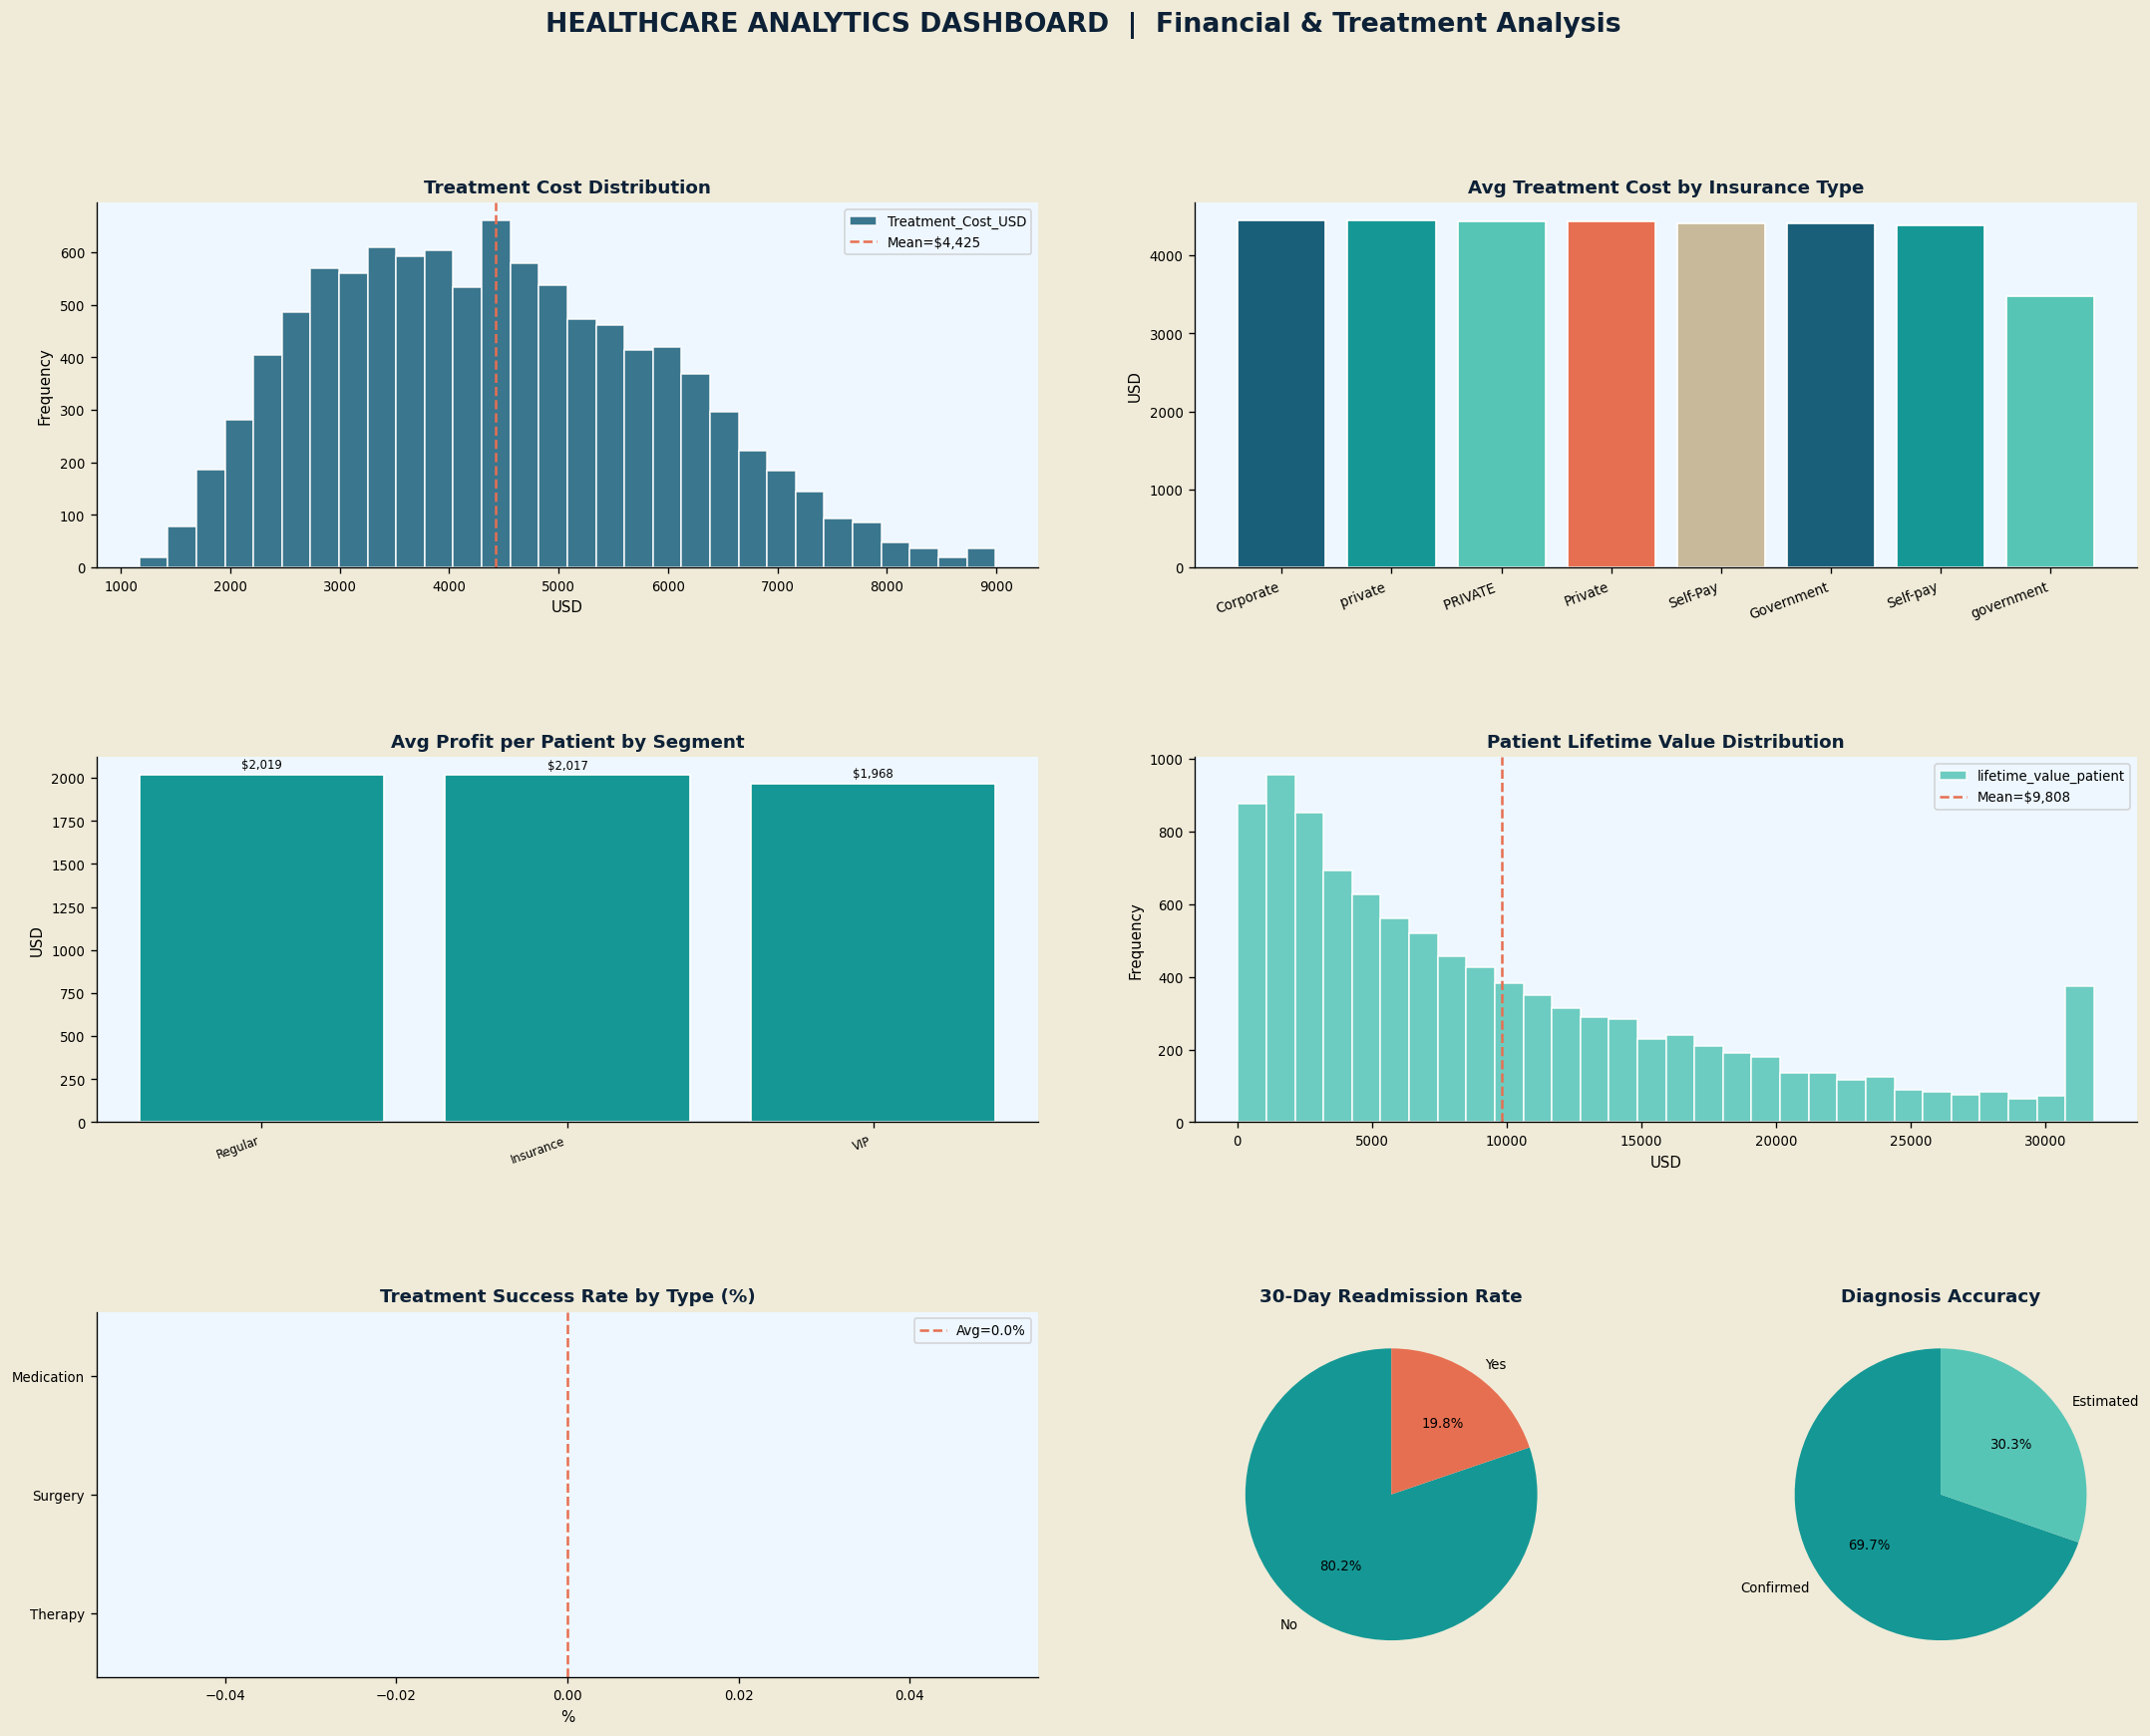

✅ Page 4 saved as dashboard_page4.png


In [26]:
# ══════════════════════════════════════════════════════════════════════════
# PAGE 4 – FINANCIAL & TREATMENT ANALYSIS
# ══════════════════════════════════════════════════════════════════════════
fig4 = plt.figure(figsize=(22, 16))
fig4.patch.set_facecolor(SAND)
gs4 = gridspec.GridSpec(3, 4, figure=fig4, hspace=0.52, wspace=0.40)

# Treatment Cost Distribution
ax = fig4.add_subplot(gs4[0, :2])
if 'Treatment_Cost_USD' in df_clean.columns:
    df_clean['Treatment_Cost_USD'].plot.hist(bins=30, color=BLUE, edgecolor='white', ax=ax, alpha=0.85)
    ax.axvline(df_clean['Treatment_Cost_USD'].mean(), color=ACCENT, linestyle='--',
               label=f"Mean=${df_clean['Treatment_Cost_USD'].mean():,.0f}")
    ax.legend(fontsize=8)
ax.set_title('Treatment Cost Distribution'); ax.set_xlabel('USD')

# Avg Cost by Insurance Type
ax = fig4.add_subplot(gs4[0, 2:])
if 'Insurance_Type' in df_clean.columns and 'Treatment_Cost_USD' in df_clean.columns:
    cost_ins = df_clean.groupby('Insurance_Type')['Treatment_Cost_USD'].mean().sort_values(ascending=False)
    ax.bar(cost_ins.index, cost_ins.values,
           color=[BLUE, TEAL, MINT, ACCENT, '#C8B99A'][:len(cost_ins)], edgecolor='white')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
    ax.set_ylabel('USD')
ax.set_title('Avg Treatment Cost by Insurance Type')

# Profit per Patient by Segment
ax = fig4.add_subplot(gs4[1, :2])
if 'patient_segment' in df_clean.columns and 'profit_per_patient' in df_clean.columns:
    prof_seg = df_clean.groupby('patient_segment')['profit_per_patient'].mean().sort_values(ascending=False)
    bars = ax.bar(prof_seg.index, prof_seg.values, color=TEAL, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f'${bar.get_height():,.0f}', ha='center', va='bottom', fontsize=7)
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=7)
    ax.set_ylabel('USD')
ax.set_title('Avg Profit per Patient by Segment')

# Lifetime Value Distribution
ax = fig4.add_subplot(gs4[1, 2:])
if 'lifetime_value_patient' in df_clean.columns:
    df_clean['lifetime_value_patient'].plot.hist(bins=30, color=MINT, edgecolor='white', ax=ax, alpha=0.85)
    ax.axvline(df_clean['lifetime_value_patient'].mean(), color=ACCENT, linestyle='--',
               label=f"Mean=${df_clean['lifetime_value_patient'].mean():,.0f}")
    ax.legend(fontsize=8)
ax.set_title('Patient Lifetime Value Distribution'); ax.set_xlabel('USD')

# Treatment Success Rate
ax = fig4.add_subplot(gs4[2, :2])
if 'treatment_type' in df_clean.columns and 'treatment_success' in df_clean.columns:
    ts = df_clean.groupby('treatment_type')['treatment_success'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
    ax.barh(ts.index[::-1], ts.values[::-1], color=TEAL, edgecolor='white')
    ax.axvline(ts.mean(), color=ACCENT, linestyle='--', label=f'Avg={ts.mean():.1f}%')
    ax.set_xlabel('%'); ax.legend(fontsize=8)
ax.set_title('Treatment Success Rate by Type (%)')

# Readmission Rate
ax = fig4.add_subplot(gs4[2, 2])
if 'readmission_30_days' in df_clean.columns:
    ra = df_clean['readmission_30_days'].value_counts()
    ax.pie(ra, labels=ra.index, autopct='%1.1f%%', colors=[TEAL, ACCENT],
           startangle=90, textprops={'fontsize': 8})
ax.set_title('30-Day Readmission Rate')

# Diagnosis Accuracy
ax = fig4.add_subplot(gs4[2, 3])
if 'diagnosis_accuracy' in df_clean.columns:
    da = df_clean['diagnosis_accuracy'].value_counts()
    ax.pie(da, labels=da.index, autopct='%1.1f%%',
           colors=[TEAL, MINT, ACCENT, BLUE][:len(da)],
           startangle=90, textprops={'fontsize': 8})
ax.set_title('Diagnosis Accuracy')

fig4.suptitle('HEALTHCARE ANALYTICS DASHBOARD  |  Financial & Treatment Analysis',
              fontsize=16, fontweight='bold', color=DARK, y=0.98)
plt.savefig('dashboard_page4.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Page 4 saved as dashboard_page4.png')

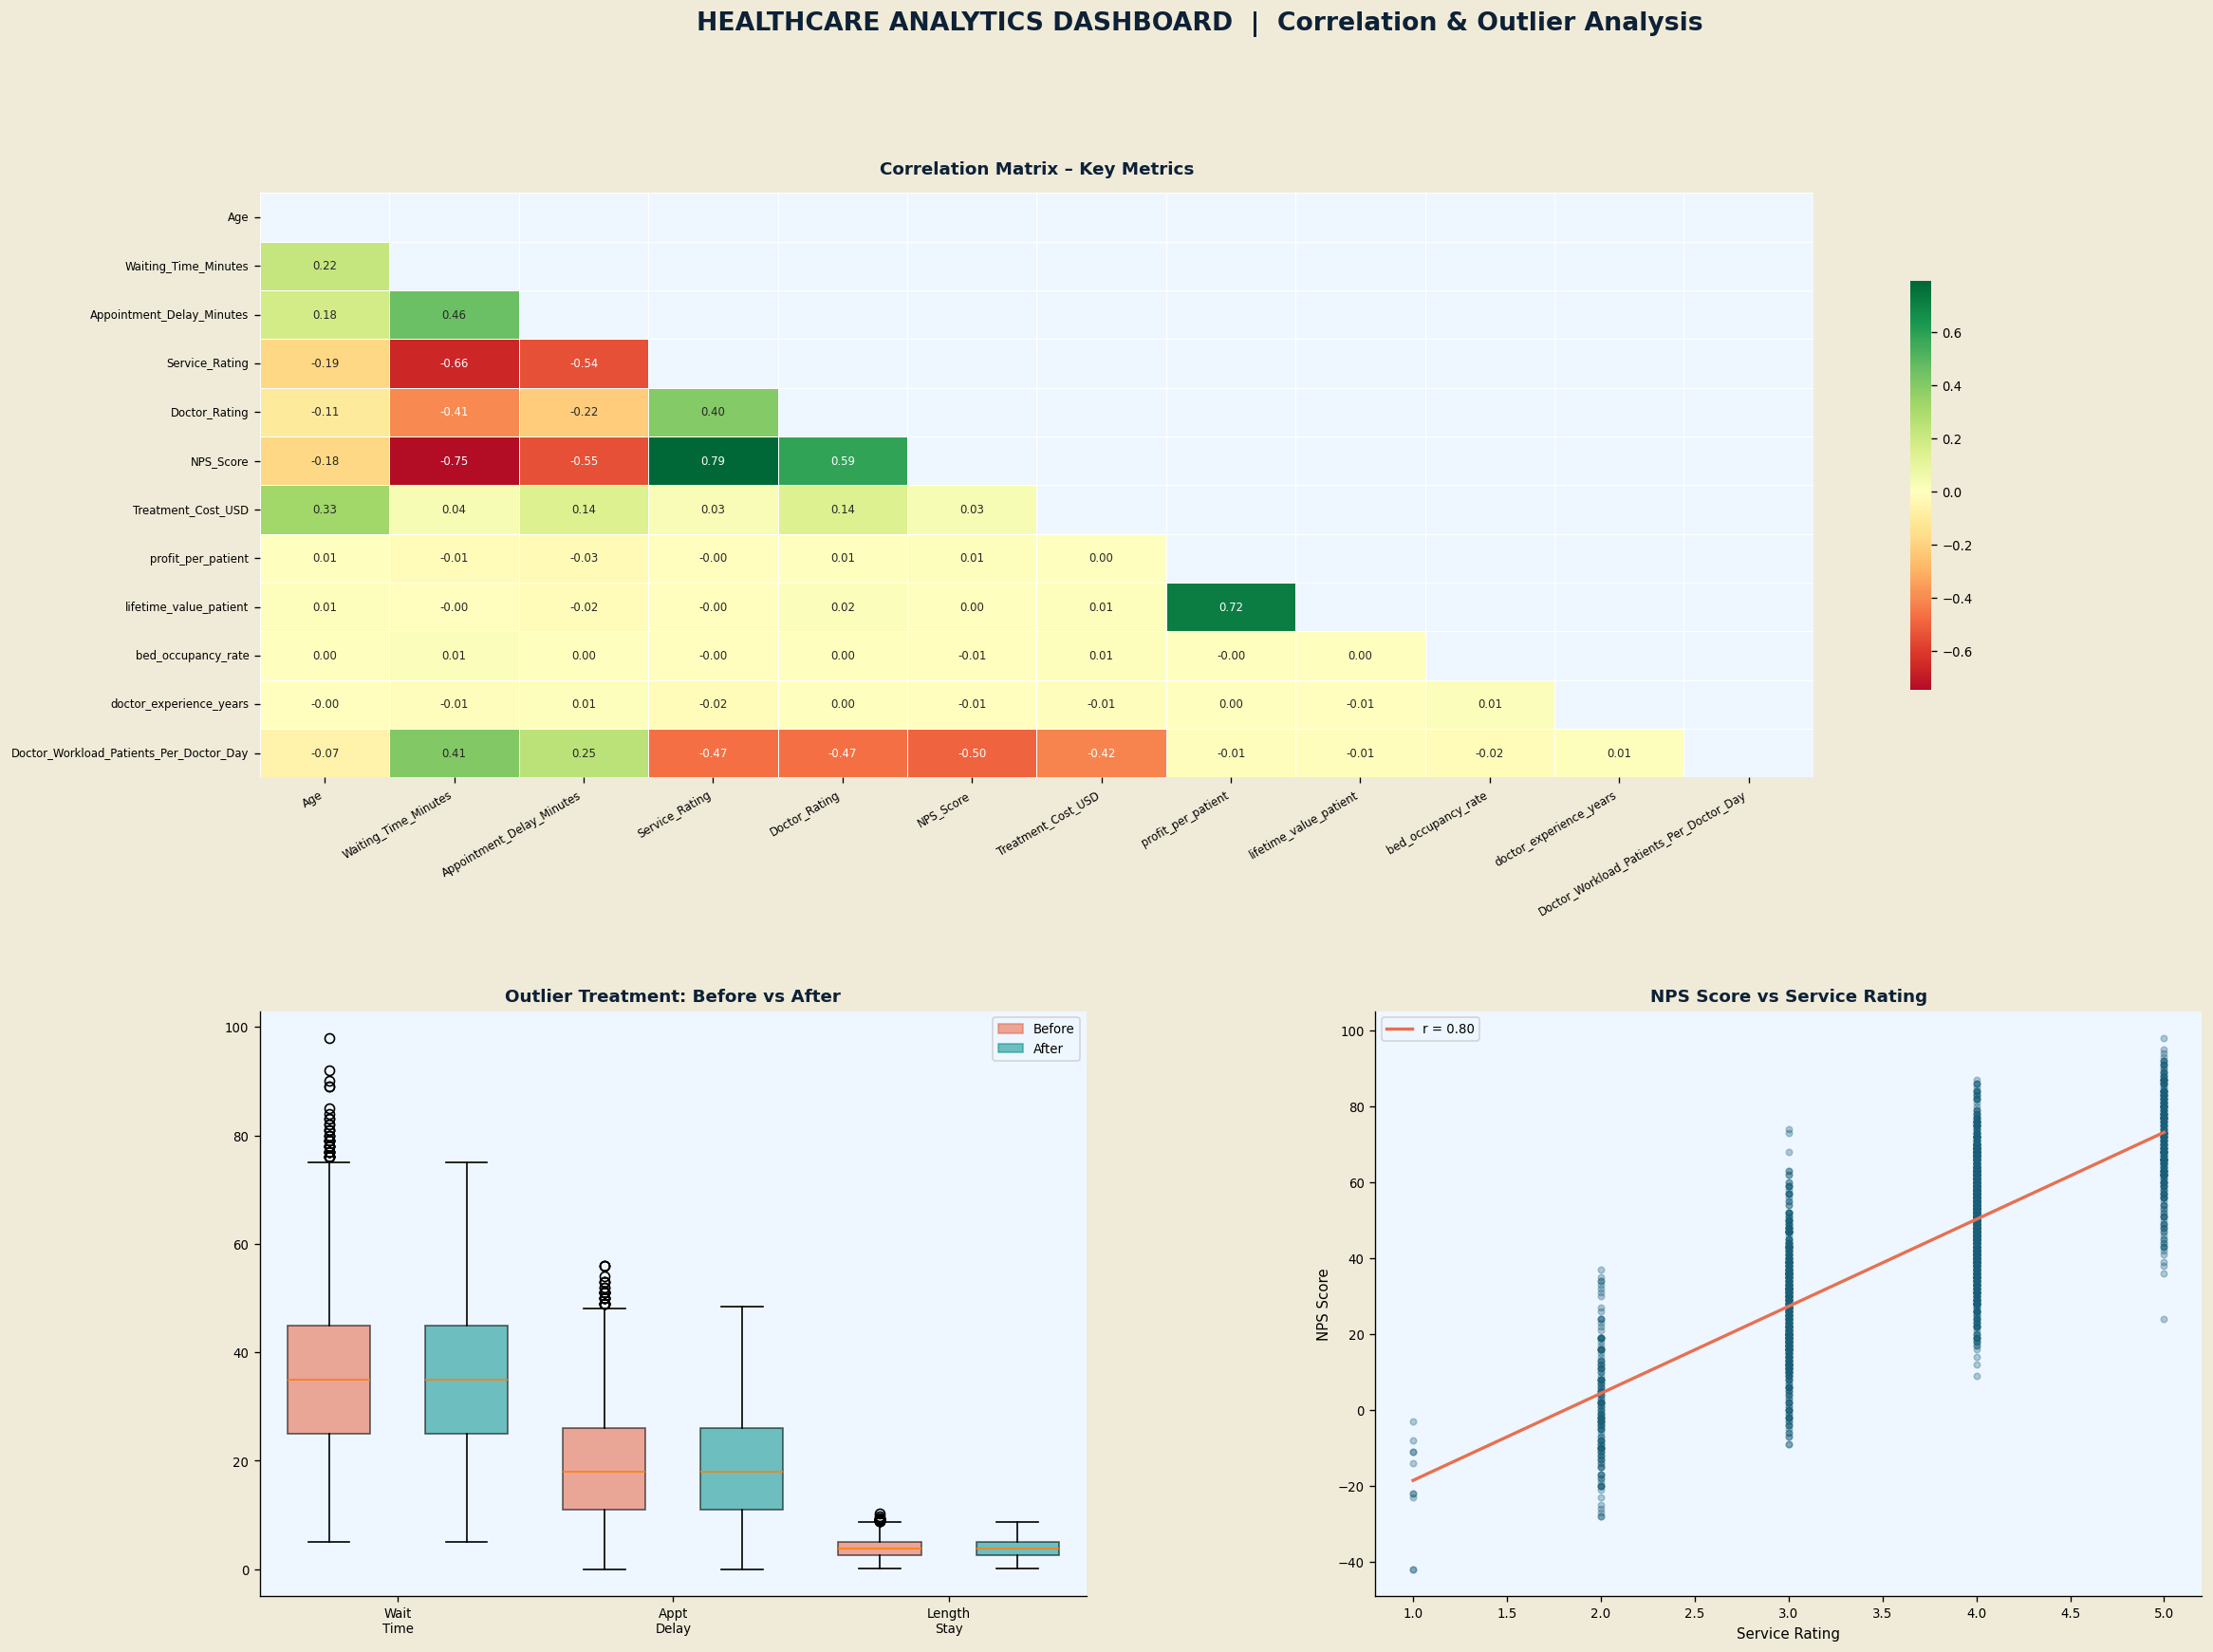

✅ Page 5 saved as dashboard_page5.png


In [27]:
# ══════════════════════════════════════════════════════════════════════════
# PAGE 5 – CORRELATION & OUTLIER ANALYSIS
# ══════════════════════════════════════════════════════════════════════════
fig5 = plt.figure(figsize=(22, 16))
fig5.patch.set_facecolor(SAND)
gs5 = gridspec.GridSpec(2, 2, figure=fig5, hspace=0.40, wspace=0.35)

# Correlation Heatmap
ax = fig5.add_subplot(gs5[0, :])
key_cols = [
    'Age','Waiting_Time_Minutes','Appointment_Delay_Minutes',
    'Service_Rating','Doctor_Rating','NPS_Score',
    'Treatment_Cost_USD','profit_per_patient','lifetime_value_patient',
    'bed_occupancy_rate','doctor_experience_years',
    'Doctor_Workload_Patients_Per_Doctor_Day'
]
key_cols = [c for c in key_cols if c in df_clean.columns]
corr = df_clean[key_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.7})
ax.set_title('Correlation Matrix – Key Metrics', pad=12)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)
plt.setp(ax.get_yticklabels(), fontsize=7)

# Before/After Outlier Boxplots
ax = fig5.add_subplot(gs5[1, 0])
box_cols = [c for c in ['Waiting_Time_Minutes','Appointment_Delay_Minutes','Length_of_Stay_Days'] if c in df_raw.columns and c in df_clean.columns]
data_before = [df_raw[c].dropna().values for c in box_cols]
data_after  = [df_clean[c].values for c in box_cols]
pos_b = [1, 3, 5][:len(box_cols)]
pos_a = [2, 4, 6][:len(box_cols)]
ax.boxplot(data_before, positions=pos_b, widths=0.6,
           patch_artist=True, boxprops=dict(facecolor=ACCENT, alpha=0.6))
ax.boxplot(data_after, positions=pos_a, widths=0.6,
           patch_artist=True, boxprops=dict(facecolor=TEAL, alpha=0.6))
ax.set_xticks([1.5, 3.5, 5.5][:len(box_cols)])
ax.set_xticklabels(['Wait\nTime','Appt\nDelay','Length\nStay'][:len(box_cols)], fontsize=8)
before_patch = mpatches.Patch(color=ACCENT, alpha=0.6, label='Before')
after_patch  = mpatches.Patch(color=TEAL,   alpha=0.6, label='After')
ax.legend(handles=[before_patch, after_patch], fontsize=8)
ax.set_title('Outlier Treatment: Before vs After')

# NPS vs Service Rating Scatter
ax = fig5.add_subplot(gs5[1, 1])
if 'Service_Rating' in df_clean.columns and 'NPS_Score' in df_clean.columns:
    sample = df_clean.sample(min(2000, len(df_clean)), random_state=42)
    ax.scatter(sample['Service_Rating'], sample['NPS_Score'],
               alpha=0.3, s=15, color=BLUE)
    m, b, r, p, _ = stats.linregress(sample['Service_Rating'], sample['NPS_Score'])
    x_line = np.array([df_clean['Service_Rating'].min(), df_clean['Service_Rating'].max()])
    ax.plot(x_line, m*x_line+b, color=ACCENT, linewidth=2, label=f'r = {r:.2f}')
    ax.set_xlabel('Service Rating'); ax.set_ylabel('NPS Score')
    ax.legend(fontsize=8)
ax.set_title('NPS Score vs Service Rating')

fig5.suptitle('HEALTHCARE ANALYTICS DASHBOARD  |  Correlation & Outlier Analysis',
              fontsize=16, fontweight='bold', color=DARK, y=0.98)
plt.savefig('dashboard_page5.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Page 5 saved as dashboard_page5.png')

In [28]:
# ── Export cleaned dataset ────────────────────────────────────────────────
df_clean.to_csv('healthcare_cleaned.csv', index=False)
df_clean.to_excel('healthcare_cleaned.xlsx', index=False)
print(f'✅ Cleaned data exported:')
print(f'   healthcare_cleaned.csv')
print(f'   healthcare_cleaned.xlsx')
print(f'   Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print('\n🎉 Full pipeline complete!')

✅ Cleaned data exported:
   healthcare_cleaned.csv
   healthcare_cleaned.xlsx
   Final shape: 10,000 rows × 53 columns

🎉 Full pipeline complete!
